In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Phase 2 Setup: Load Phase 1 outputs + standard config
# ════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import glob, os, warnings
warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────
ROOT  = '/content/drive/MyDrive/NSII_Research'
ONET  = f'{ROOT}/onet'
BLS   = f'{ROOT}/bls'
IPUMS = f'{ROOT}/IPUMS'
HMDA  = f'{ROOT}/hmda'
FRED  = f'{ROOT}/fred'
AUTO  = f'{ROOT}'
P2    = f'{ROOT}/phase2'
os.makedirs(P2, exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (13, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
})

# ── Load Phase 1 parquet outputs ─────────────────────────────────
print("Loading Phase 1 outputs...")
automation = pd.read_parquet(f'{ROOT}/automation_risk_31occ.parquet')
cps_workers = pd.read_parquet(f'{ROOT}/cps_workers_midwest.parquet')
skills_imp  = pd.read_parquet(f'{ROOT}/skills_target_31occ.parquet')
felten_geo  = pd.read_parquet(f'{ROOT}/felten_county_aige.parquet')

# ── Verify Phase 1 outputs ────────────────────────────────────────
assert len(automation) == 31,       f"Expected 31 automation rows, got {len(automation)}"
assert automation['DR'].isna().sum() == 0, "NaN DR values in automation file"
assert len(cps_workers) == 78327,   f"Expected 78,327 CPS workers, got {len(cps_workers)}"
assert len(felten_geo)  == 3271,    f"Expected 3,271 county rows, got {len(felten_geo)}"

print(f"  automation_risk_31occ : {len(automation):3} rows ✔")
print(f"  cps_workers_midwest   : {len(cps_workers):,} rows ✔")
print(f"  skills_target_31occ   : {len(skills_imp):,} rows ✔")
print(f"  felten_county_aige    : {len(felten_geo):,} rows ✔")
print(f"  Phase2 output folder  : {P2} ✔")

# ── Reload TARGET_SOC and supporting structures from Phase 1 ─────
TARGET_SOC = [
    '43-3031.00','43-9061.00','43-4051.00','43-1011.00','23-2011.00',
    '41-2031.00','51-9061.00','53-7051.00','43-5061.00','13-2011.00',
    '51-4041.00','51-4121.00','51-2041.00','49-9041.00','17-2141.00',
    '17-2112.00','11-3051.00','51-1011.00','51-4081.00','17-3026.00',
    '15-1252.00','15-1211.00','15-1244.00','15-1231.00','13-1161.00',
    '11-2021.00','29-2011.00','17-2061.00','15-2031.00','11-9041.00',
    '15-2051.00',
]
TARGET_NAMES = {
    '43-3031.00':'Bookkeeping Clerks','43-9061.00':'Office Clerks',
    '43-4051.00':'Customer Service Reps','43-1011.00':'Office Supervisors',
    '23-2011.00':'Paralegals','41-2031.00':'Retail Salespersons',
    '51-9061.00':'Inspectors/Testers','53-7051.00':'Industrial Truck Operators',
    '43-5061.00':'Production Planners','13-2011.00':'Accountants',
    '51-4041.00':'Machinists','51-4121.00':'Welders',
    '51-2041.00':'Metal Fabricators','49-9041.00':'Machinery Mechanics',
    '17-2141.00':'Mechanical Engineers','17-2112.00':'Industrial Engineers',
    '11-3051.00':'Production Managers','51-1011.00':'Production Supervisors',
    '51-4081.00':'Multiple Machine Tool Setters','17-3026.00':'Industrial Eng. Technicians',
    '15-1252.00':'Software Developers','15-1211.00':'Computer Systems Analysts',
    '15-1244.00':'Network Administrators','15-1231.00':'Network Support Specialists',
    '13-1161.00':'Market Research Analysts','11-2021.00':'Marketing Managers',
    '29-2011.00':'Medical Lab Technologists','17-2061.00':'Computer Hardware Engineers',
    '15-2031.00':'Operations Research Analysts','11-9041.00':'Architectural/Eng. Managers',
    '15-2051.00':'Data Scientists',
}
GROUP_LABELS = {
    'AI_DISPLACED':['43-3031.00','43-9061.00','43-4051.00','43-1011.00','23-2011.00',
                    '41-2031.00','51-9061.00','53-7051.00','43-5061.00','13-2011.00'],
    'MIDWEST_MFG': ['51-4041.00','51-4121.00','51-2041.00','49-9041.00','17-2141.00',
                    '17-2112.00','11-3051.00','51-1011.00','51-4081.00','17-3026.00'],
    'RESKILLING_TARGETS':['15-1252.00','15-1211.00','15-1244.00','15-1231.00','13-1161.00',
                          '11-2021.00','29-2011.00','17-2061.00','15-2031.00','11-9041.00',
                          '15-2051.00'],
}

TARGET_7 = [s[:7] for s in TARGET_SOC]   # 7-char SOC keys for all merges

# Convenience: group membership lookup
SOC_TO_GROUP = {}
for grp, codes in GROUP_LABELS.items():
    for code in codes:
        SOC_TO_GROUP[code] = grp

print("\nPhase 1 outputs verified. Phase 2 environment ready.")
print(f"TARGET_SOC: {len(TARGET_SOC)} occupations across {len(GROUP_LABELS)} groups.")

Mounted at /content/drive
Loading Phase 1 outputs...
  automation_risk_31occ :  31 rows ✔
  cps_workers_midwest   : 78,327 rows ✔
  skills_target_31occ   : 1,050 rows ✔
  felten_county_aige    : 3,271 rows ✔
  Phase2 output folder  : /content/drive/MyDrive/NSII_Research/phase2 ✔

Phase 1 outputs verified. Phase 2 environment ready.
TARGET_SOC: 31 occupations across 3 groups.


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — SV: Skill Velocity from OEWS Employment Growth
# FIXED: auto-detects actual filter values instead of hardcoding
# ════════════════════════════════════════════════════════════════
import glob

# ── Step 1: Reload OEWS with standardised columns ────────────────
oews_frames = []
for yr in range(2019, 2025):
    pattern = f'{BLS}/oesm{str(yr)[2:]}nat/national_M{yr}_dl.xlsx'
    files   = glob.glob(pattern)
    if not files:
        print(f"  OEWS {yr}: NOT FOUND")
        continue
    df = pd.read_excel(files[0], dtype=str)
    df.columns = df.columns.str.lower().str.strip()
    df = df.loc[:, ~df.columns.duplicated(keep='first')]
    df['survey_year'] = yr
    oews_frames.append(df)
    print(f"  OEWS {yr}: {len(df):,} rows")

oews = pd.concat(oews_frames, ignore_index=True)
oews['soc_clean'] = oews['occ_code'].astype(str).str.strip()
print(f"\nOEWS combined: {len(oews):,} rows")

# ── Step 2: Discover actual filter column values ──────────────────
print("\nOEWS filter column discovery (actual unique values):")
for col in ['i_group','own_code','naics','area_type']:
    if col in oews.columns:
        vals = oews[col].value_counts().to_dict()
        print(f"  {col:<12}: {vals}")

# ── Step 3: Smart national-total filter ───────────────────────────
# Strategy: use all rows that have naics='000000' (cross-industry national)
# The own_code value varies by OEWS vintage — do NOT hardcode '1'
# Instead: if naics='000000' is the ONLY naics value present, use all rows
naics_col    = 'naics'    if 'naics'     in oews.columns else None
igroup_col   = 'i_group'  if 'i_group'   in oews.columns else None

if naics_col and oews[naics_col].astype(str).str.strip().eq('000000').all():
    # Every row is already cross-industry national total — use all rows
    oews_nat = oews.copy()
    print("\nAll rows are cross-industry national totals — using full dataset ✔")

elif naics_col:
    # Filter to cross-industry rows only
    oews_nat = oews[oews[naics_col].astype(str).str.strip() == '000000'].copy()
    print(f"\nFiltered to naics='000000': {len(oews_nat):,} rows")

    # If multiple own_code values exist, keep the most-common one (usually all-ownership)
    if 'own_code' in oews_nat.columns:
        most_common_own = oews_nat['own_code'].value_counts().idxmax()
        own_counts = oews_nat['own_code'].value_counts()
        if len(own_counts) > 1:
            oews_nat = oews_nat[oews_nat['own_code'] == most_common_own].copy()
            print(f"Filtered to most common own_code='{most_common_own}': "
                  f"{len(oews_nat):,} rows")
        else:
            print(f"Only one own_code value ('{most_common_own}') — no filter needed")
else:
    oews_nat = oews.copy()
    print("No naics column found — using all rows")

assert len(oews_nat) > 0, "oews_nat is empty after filtering — check OEWS structure"
print(f"\nFinal national rows for SV computation: {len(oews_nat):,}")

# ── Step 4: Coerce numeric columns ───────────────────────────────
oews_nat['tot_emp'] = pd.to_numeric(oews_nat['tot_emp'], errors='coerce')
oews_nat['a_mean']  = pd.to_numeric(oews_nat['a_mean'],  errors='coerce')

# ── Step 5: Add proxy for 29-2011 using parent group 29-2010 ──────
proxy = oews_nat[oews_nat['soc_clean'] == '29-2010'].copy()
if len(proxy) > 0:
    proxy['soc_clean'] = '29-2011'
    oews_nat = pd.concat([oews_nat, proxy], ignore_index=True)
    print("Proxy for 29-2011 from parent 29-2010 ✔")
else:
    print("WARNING: 29-2010 not found — 29-2011 will use median SV fallback")

# ── Step 6: Filter to target occupations ─────────────────────────
target_emp = oews_nat[oews_nat['soc_clean'].isin(TARGET_7)].copy()
print(f"\nOEWS rows matching 31 target SOC codes: {len(target_emp):,}")
print(f"Unique occupations matched: {target_emp['soc_clean'].nunique()} of 31")

missing_oews = set(TARGET_7) - set(target_emp['soc_clean'].unique())
if missing_oews:
    print(f"Missing from OEWS: {missing_oews}")

# Show what we have per year per occupation
occ_year_counts = (target_emp.groupby(['soc_clean','survey_year'])
                   .size().unstack(fill_value=0))
print(f"\nOccupation × year coverage ({occ_year_counts.shape[0]} occ × "
      f"{occ_year_counts.shape[1]} years):")
print(occ_year_counts)

# ── Step 7: Employment pivot ──────────────────────────────────────
# If multiple rows per occ×year (different i_group subtotals), take mean
emp_pivot = (target_emp
    .groupby(['soc_clean','survey_year'])['tot_emp']
    .mean()
    .unstack(level='survey_year'))

print(f"\nEmployment pivot: {emp_pivot.shape}")
nan_cells = emp_pivot.isna().sum().sum()
print(f"Suppressed (NaN) cells: {nan_cells}")

# ── Step 8: Compute Skill Velocity (CAGR 2019→2024) ──────────────
sv_rows = []
for soc in TARGET_7:
    occ_name = TARGET_NAMES.get(soc + '.00', soc)

    if soc not in emp_pivot.index:
        sv_rows.append({'soc_7': soc, 'occ_name': occ_name,
                        'emp_start': np.nan, 'emp_end': np.nan,
                        'SV_raw': np.nan, 'SV_note': 'no OEWS data'})
        continue

    row = emp_pivot.loc[soc]

    # Primary: 2019 → 2024 (5-year CAGR)
    e_start = row.get(2019, np.nan)
    e_end   = row.get(2024, np.nan)
    n_yrs   = 5

    # Fallback: widest available window if endpoints suppressed
    if pd.isna(e_start) or pd.isna(e_end):
        avail = row.dropna()
        if len(avail) >= 2:
            yr_s = avail.index.min()
            yr_e = avail.index.max()
            e_start, e_end = avail[yr_s], avail[yr_e]
            n_yrs = yr_e - yr_s
        else:
            sv_rows.append({'soc_7': soc, 'occ_name': occ_name,
                            'emp_start': np.nan, 'emp_end': np.nan,
                            'SV_raw': np.nan, 'SV_note': 'insufficient OEWS data'})
            continue

    # CAGR = (end/start)^(1/n) − 1
    if e_start > 0 and e_end > 0 and n_yrs > 0:
        cagr = (float(e_end) / float(e_start)) ** (1.0 / n_yrs) - 1.0
    else:
        cagr = np.nan

    sv_rows.append({
        'soc_7':     soc,
        'occ_name':  occ_name,
        'emp_start': e_start,
        'emp_end':   e_end,
        'SV_raw':    cagr,
        'SV_note':   ('CAGR 2019-2024' if n_yrs == 5
                      else f'CAGR {n_yrs}yr fallback'),
    })

sv_df = pd.DataFrame(sv_rows)

n_valid = sv_df['SV_raw'].notna().sum()
n_nan   = sv_df['SV_raw'].isna().sum()
print(f"\nSV_raw computed: {n_valid} occupations | {n_nan} NaN (to be filled)")
print(f"SV_raw range:    {sv_df['SV_raw'].min():.4f} to {sv_df['SV_raw'].max():.4f}")

# ── Step 9: Fill NaN SV with group-median fallback ────────────────
# Never drop an occupation — use group median so NaN cases
# (e.g. 29-2011 proxy missing) still get a meaningful SV
sv_df['group'] = sv_df['soc_7'].apply(
    lambda s: SOC_TO_GROUP.get(s + '.00', 'UNKNOWN'))

for grp in sv_df['group'].unique():
    grp_median = sv_df.loc[sv_df['group'] == grp, 'SV_raw'].median()
    mask = (sv_df['group'] == grp) & sv_df['SV_raw'].isna()
    if mask.any():
        sv_df.loc[mask, 'SV_raw']  = grp_median
        sv_df.loc[mask, 'SV_note'] = f'group-median fallback ({grp})'
        print(f"  Fallback SV_raw={grp_median:.4f} for "
              f"{mask.sum()} occ in {grp}")

# Final global median fill for any remaining NaN
global_med = sv_df['SV_raw'].median()
sv_df['SV_raw'] = sv_df['SV_raw'].fillna(global_med)

# ── Step 10: Normalise SV to [0,1] ───────────────────────────────
sv_min   = sv_df['SV_raw'].min()
sv_max   = sv_df['SV_raw'].max()
sv_range = sv_max - sv_min

if sv_range < 1e-9:
    # Degenerate case: all occupations grew at the same rate
    # Assign uniform SV = 0.5 and document
    print("WARNING: All SV_raw values are identical — assigning uniform SV=0.5")
    sv_df['SV'] = 0.5
else:
    sv_df['SV'] = ((sv_df['SV_raw'] - sv_min) / sv_range).clip(0, 1)

# Final assertions
assert sv_df['SV'].isna().sum() == 0,         "NaN SV values remain"
assert sv_df['SV'].between(0, 1).all(),        "SV values outside [0,1]"
assert len(sv_df) == 31,                       f"Expected 31 SV rows, got {len(sv_df)}"

# ── Step 11: Sanity check ─────────────────────────────────────────
print(f"\nSV range: {sv_min:.4f} to {sv_max:.4f}  ({sv_range:.4f} span)")
print(f"SV normalised: min={sv_df['SV'].min():.3f}  max={sv_df['SV'].max():.3f}")
print(f"\nFull SV table (sorted by SV descending):")
print(f"  {'SOC':<10} {'SV_raw':>8} {'SV':>6}  {'Note':<25}  Occupation")
print("  " + "─" * 80)
for _, row in sv_df.sort_values('SV', ascending=False).iterrows():
    print(f"  {row['soc_7']:<10} {row['SV_raw']:>8.4f} {row['SV']:>6.3f}"
          f"  {row['SV_note']:<25}  {row['occ_name']}")

# Directional sanity checks
sw_dev = sv_df[sv_df['soc_7'] == '15-1252']['SV_raw'].values
bk_clk = sv_df[sv_df['soc_7'] == '43-3031']['SV_raw'].values
if len(sw_dev) and len(bk_clk):
    print(f"\nDirectional checks:")
    print(f"  Software Developers  (expect growing):  SV_raw={sw_dev[0]:>8.4f}")
    print(f"  Bookkeeping Clerks   (expect declining): SV_raw={bk_clk[0]:>8.4f}")
    if sw_dev[0] > bk_clk[0]:
        print("  ✔ Software Devs grow faster than Bookkeeping Clerks — as expected")
    else:
        print("  ⚠ Direction unexpected — review OEWS employment data")

print("\nCell 2 complete. SV computed for all 31 occupations. ✔")

  OEWS 2019: 1,329 rows
  OEWS 2020: 1,329 rows
  OEWS 2021: 1,403 rows
  OEWS 2022: 1,402 rows
  OEWS 2023: 1,403 rows
  OEWS 2024: 1,403 rows

OEWS combined: 8,269 rows

OEWS filter column discovery (actual unique values):
  i_group     : {'cross-industry': 8269}
  own_code    : {'1235': 8269}
  naics       : {'000000': 8269}
  area_type   : {'1': 8269}

All rows are cross-industry national totals — using full dataset ✔

Final national rows for SV computation: 8,269
Proxy for 29-2011 from parent 29-2010 ✔

OEWS rows matching 31 target SOC codes: 188
Unique occupations matched: 31 of 31

Occupation × year coverage (31 occ × 6 years):
survey_year  2019  2020  2021  2022  2023  2024
soc_clean                                      
11-2021         1     1     1     1     1     1
11-3051         1     1     1     1     1     1
11-9041         1     1     1     1     1     1
13-1161         1     1     1     1     1     1
13-2011         1     1     1     1     1     1
15-1211         1    

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — MDI: Market Demand Index from O*NET Work Activities
#
# Methodology:
#   Primary: mean Work Activity Importance score per occupation
#            (O*NET rates 41 generalised work activities on 1–5 scale)
#   Secondary: OEWS employment level (absolute size of labour market)
#   MDI = 0.7 × activity_importance_norm + 0.3 × employment_level_norm
#   Normalise each component to [0,1] before weighting
#   For Data Scientists (15-2051, missing from skills): check Work Activities
# ════════════════════════════════════════════════════════════════

# ── Step 1: Load Work Activities (already in O*NET folder) ───────
work_act = pd.read_excel(f'{ONET}/Work Activities.xlsx')

print(f"Work Activities raw: {len(work_act):,} rows × {work_act.shape[1]} cols")
print(f"Columns: {list(work_act.columns)}")
print(f"\nScale Name unique values: {work_act['Scale Name'].unique()}")
print(f"Occupations total: {work_act['O*NET-SOC Code'].nunique()}")

# ── Step 2: Filter to Importance scale for 31 target occupations ─
wa_imp = work_act[
    (work_act['O*NET-SOC Code'].isin(TARGET_SOC)) &
    (work_act['Scale Name'] == 'Importance')
].copy()

wa_imp['Data Value'] = pd.to_numeric(wa_imp['Data Value'], errors='coerce')

occ_in_wa = wa_imp['O*NET-SOC Code'].nunique()
print(f"\nWork Activities — Importance scale:")
print(f"  Rows:        {len(wa_imp):,}")
print(f"  Occupations: {occ_in_wa} of {len(TARGET_SOC)}")

missing_wa = [s for s in TARGET_SOC
              if s not in wa_imp['O*NET-SOC Code'].unique()]
if missing_wa:
    print(f"  Missing: {missing_wa}")
    print(f"  NOTE: These occupations will use group-mean MDI imputation")
else:
    print(f"  All {len(TARGET_SOC)} occupations have Work Activity data ✔")

# ── Step 3: Mean importance per occupation ────────────────────────
wa_mean = (wa_imp
    .groupby('O*NET-SOC Code')['Data Value']
    .agg(mean_importance='mean', n_activities='count')
    .reset_index())
wa_mean['soc_7'] = wa_mean['O*NET-SOC Code'].str[:7]

print(f"\nWork activity importance range: "
      f"{wa_mean['mean_importance'].min():.3f} – "
      f"{wa_mean['mean_importance'].max():.3f}")

# ── Step 4: Employment level from OEWS (national 2024) ───────────
emp_2024 = (oews_nat[
    (oews_nat['soc_clean'].isin(TARGET_7)) &
    (oews_nat['survey_year'] == 2024)
][['soc_clean','tot_emp']].copy())

# Proxy for 29-2011 if still missing
if '29-2011' not in emp_2024['soc_clean'].values:
    proxy_emp = oews_nat[
        (oews_nat['soc_clean'] == '29-2010') &
        (oews_nat['survey_year'] == 2024)
    ][['soc_clean','tot_emp']].copy()
    proxy_emp['soc_clean'] = '29-2011'
    emp_2024 = pd.concat([emp_2024, proxy_emp], ignore_index=True)

emp_2024 = emp_2024.rename(columns={'soc_clean':'soc_7','tot_emp':'emp_level'})
emp_2024 = emp_2024.groupby('soc_7')['emp_level'].mean().reset_index()

print(f"\nEmployment level coverage: {len(emp_2024)} of {len(TARGET_SOC)} occupations")

# ── Step 5: Merge Work Activities + Employment ────────────────────
mdi_df = pd.DataFrame({'soc_7': TARGET_7})
mdi_df = mdi_df.merge(
    wa_mean[['soc_7','mean_importance']], on='soc_7', how='left'
).merge(
    emp_2024[['soc_7','emp_level']], on='soc_7', how='left'
)
mdi_df['occ_name'] = mdi_df['soc_7'].map(
    {k[:7]: v for k, v in TARGET_NAMES.items()})

# ── Step 6: Normalise each component then compute MDI ─────────────
def norm_col(series):
    s_min, s_max = series.min(), series.max()
    if s_max == s_min:
        return pd.Series(np.ones(len(series)), index=series.index)
    return ((series - s_min) / (s_max - s_min)).clip(0, 1)

# Impute missing Work Activity scores with group mean per occupation group
group_means_wa = {}
for grp, codes in GROUP_LABELS.items():
    grp_socs = [c[:7] for c in codes]
    vals = mdi_df[mdi_df['soc_7'].isin(grp_socs)]['mean_importance'].dropna()
    group_means_wa[grp] = vals.mean() if len(vals) > 0 else mdi_df['mean_importance'].mean()

for _, row in mdi_df[mdi_df['mean_importance'].isna()].iterrows():
    soc = row['soc_7'] + '.00'
    grp = SOC_TO_GROUP.get(soc, None)
    fill = group_means_wa.get(grp, mdi_df['mean_importance'].median())
    mdi_df.loc[mdi_df['soc_7'] == row['soc_7'], 'mean_importance'] = fill
    print(f"  Imputed mean_importance for {row['soc_7']} "
          f"({TARGET_NAMES.get(soc,'?')}) = {fill:.3f}")

# Same for employment
med_emp = mdi_df['emp_level'].median()
mdi_df['emp_level'] = mdi_df['emp_level'].fillna(med_emp)

# Normalise both components
mdi_df['wa_norm']  = norm_col(mdi_df['mean_importance'])
mdi_df['emp_norm'] = norm_col(mdi_df['emp_level'])

# Weighted MDI: 70% work activity importance, 30% employment level
mdi_df['MDI'] = (0.70 * mdi_df['wa_norm'] + 0.30 * mdi_df['emp_norm']).clip(0, 1)

# ── Step 7: Validation assertions ────────────────────────────────
assert mdi_df['MDI'].isna().sum() == 0, "NaN MDI values remain"
assert mdi_df['MDI'].between(0, 1).all(), "MDI values outside [0,1]"
assert len(mdi_df) == 31, f"Expected 31 MDI rows, got {len(mdi_df)}"

print("\nMDI Sanity Check:")
print(f"  {'Occupation':<35} {'WA_imp':>7} {'Emp_norm':>9} {'MDI':>6}")
print("  " + "─" * 60)
for _, row in mdi_df.sort_values('MDI', ascending=False).iterrows():
    print(f"  {row['occ_name']:<35} {row['mean_importance']:>7.3f} "
          f"{row['emp_norm']:>9.3f} {row['MDI']:>6.3f}")

print(f"\nMDI range: {mdi_df['MDI'].min():.3f} – {mdi_df['MDI'].max():.3f}")
print("Note: Reskilling targets should show higher MDI than displaced occupations.")

Work Activities raw: 73,308 rows × 15 cols
Columns: ['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Not Relevant', 'Date', 'Domain Source']

Scale Name unique values: ['Importance' 'Level']
Occupations total: 894

Work Activities — Importance scale:
  Rows:        1,230
  Occupations: 30 of 31
  Missing: ['15-2051.00']
  NOTE: These occupations will use group-mean MDI imputation

Work activity importance range: 2.458 – 3.599

Employment level coverage: 31 of 31 occupations
  Imputed mean_importance for 15-2051 (Data Scientists) = 3.192

MDI Sanity Check:
  Occupation                           WA_imp  Emp_norm    MDI
  ────────────────────────────────────────────────────────────
  Medical Lab Technologists             3.599     0.077  0.723
  Production Supervisors                3.530     0.169  0.708
  Customer Service Reps                 3.237     0.713

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — TI: Transferability Index
# FIXED Mi4: Now identifies which 2 occupations have no
#            Related Occupations signal
# ════════════════════════════════════════════════════════════════

# ── Step 1: Load Skills table ─────────────────────────────────────
skills_all = pd.read_excel(f'{ONET}/Skills.xlsx')
skills_all['Data Value'] = pd.to_numeric(skills_all['Data Value'], errors='coerce')

print(f"Skills raw: {len(skills_all):,} rows")
print(f"Scale Name values: {skills_all['Scale Name'].unique()}")

# ── Step 2: Importance scale distribution ────────────────────────
imp_all    = skills_all[skills_all['Scale Name'] == 'Importance'].copy()
imp_target = imp_all[imp_all['O*NET-SOC Code'].isin(TARGET_SOC)].copy()

print(f"\nImportance scores for 31 target occupations:")
print(f"  Total rows:  {len(imp_target):,}")
print(f"  Mean:        {imp_target['Data Value'].mean():.3f}")
print(f"  Median:      {imp_target['Data Value'].median():.3f}")
print(f"  75th pctile: {imp_target['Data Value'].quantile(0.75):.3f}")
print(f"  90th pctile: {imp_target['Data Value'].quantile(0.90):.3f}")
for thresh in [2.5, 3.0, 3.25, 3.5]:
    n = (imp_target['Data Value'] >= thresh).sum()
    print(f"  >= {thresh}: {n:,} rows")

# ── Step 3: Adaptive top-N strategy ──────────────────────────────
TOP_N = 10
print(f"\nUsing top-{TOP_N} skills per occupation by Importance score")

skill_sets = {}
for soc in TARGET_SOC:
    occ_skills = imp_target[
        imp_target['O*NET-SOC Code'] == soc
    ].nlargest(TOP_N, 'Data Value')
    skill_sets[soc] = set(occ_skills['Element Name'].unique())

# ── Step 4: Handle 15-2051 Data Scientists ────────────────────────
ds_imp = imp_target[imp_target['O*NET-SOC Code'] == '15-2051.00']
print(f"\n15-2051 Data Scientists Importance rows: {len(ds_imp)}")

TI_QUALITY_FLAGS = {}

if len(skill_sets.get('15-2051.00', set())) == 0:
    ds_level = skills_all[
        (skills_all['O*NET-SOC Code'] == '15-2051.00') &
        (skills_all['Scale Name'] == 'Level')
    ].nlargest(TOP_N, 'Data Value')

    if len(ds_level) >= 3:
        skill_sets['15-2051.00'] = set(ds_level['Element Name'].unique())
        TI_QUALITY_FLAGS['15-2051.00'] = 'Level-scale proxy'
        print(f"  → Using Level-scale skills as proxy ✔")
    else:
        wa = pd.read_excel(f'{ONET}/Work Activities.xlsx')
        wa['Data Value'] = pd.to_numeric(wa['Data Value'], errors='coerce')
        ds_wa = wa[
            (wa['O*NET-SOC Code'] == '15-2051.00') &
            (wa['Scale Name'] == 'Importance')
        ].nlargest(TOP_N, 'Data Value')

        if len(ds_wa) >= 3:
            skill_sets['15-2051.00'] = set(ds_wa['Element Name'].unique())
            TI_QUALITY_FLAGS['15-2051.00'] = 'Work Activities proxy'
            print(f"  → Using Work Activities proxy ✔")
        else:
            skill_sets['15-2051.00'] = skill_sets.get('15-2031.00', set()).copy()
            TI_QUALITY_FLAGS['15-2051.00'] = 'Nearest-neighbour proxy (15-2031)'
            print(f"  → Using 15-2031 Operations Research Analysts as "
                  f"nearest-neighbour proxy")
            print(f"    NOTE: Creates identical Jaccard scores for "
                  f"15-2051 and 15-2031")
            print(f"    Phase 3 GNN distinguishes these via SV, MDI, DR node features")

# ── Step 5: Skill set coverage ────────────────────────────────────
occ_skill_counts = {k: len(v) for k, v in skill_sets.items()}
print(f"\nSkill set sizes: min={min(occ_skill_counts.values())}  "
      f"max={max(occ_skill_counts.values())}  "
      f"mean={sum(occ_skill_counts.values())/len(occ_skill_counts):.1f}")

zero_skill = [k for k, v in occ_skill_counts.items() if v == 0]
if zero_skill:
    for soc in zero_skill:
        grp      = SOC_TO_GROUP.get(soc, 'RESKILLING_TARGETS')
        fallback = max(
            [c for c in GROUP_LABELS[grp]
             if c != soc and occ_skill_counts.get(c, 0) > 0],
            key=lambda c: occ_skill_counts.get(c, 0), default=None)
        if fallback:
            skill_sets[soc] = skill_sets[fallback].copy()
            occ_skill_counts[soc] = len(skill_sets[soc])
            TI_QUALITY_FLAGS[soc] = f'Group fallback from {fallback[:7]}'
            print(f"  {soc}: fallback to {TARGET_NAMES[fallback]} ✔")
else:
    print("All 31 occupations have skill sets. ✔")

all_skills = set()
for s in skill_sets.values():
    all_skills |= s
print(f"\nVocabulary: {len(all_skills)} unique skills")
print(f"Skills: {sorted(all_skills)}")

# ── Step 6: Pairwise Jaccard matrix ──────────────────────────────
def jaccard(a, b):
    if not a and not b: return 0.0
    union = a | b
    return len(a & b) / len(union) if union else 0.0

n = len(TARGET_SOC)
J = np.zeros((n, n))
for i, soc_i in enumerate(TARGET_SOC):
    for j, soc_j in enumerate(TARGET_SOC):
        J[i, j] = jaccard(skill_sets[soc_i], skill_sets[soc_j])

jaccard_df = pd.DataFrame(J, index=TARGET_SOC, columns=TARGET_SOC)

assert J.shape == (31, 31)
assert (np.diag(J) == 1.0).all()
assert (J >= 0).all() and (J <= 1).all()
off_diag = J[~np.eye(n, dtype=bool)]
print(f"\nJaccard matrix: {jaccard_df.shape} ✔")
print(f"Off-diagonal range: {off_diag.min():.4f} – {off_diag.max():.4f}")
print(f"Mean off-diagonal:  {off_diag.mean():.4f}")

perfect_pairs = [(TARGET_SOC[i], TARGET_SOC[j])
                 for i in range(n) for j in range(i+1, n) if J[i,j] == 1.0]
if perfect_pairs:
    print(f"\nPairs with Jaccard=1.0 (identical skill sets — proxy artefact):")
    for a, b in perfect_pairs:
        print(f"  {a[:7]} {TARGET_NAMES[a]} ↔ {b[:7]} {TARGET_NAMES[b]}")
    print(f"  NOTE: Phase 3 GNN distinguishes these via "
          f"different SV, MDI, DR node features")

# ── Step 7: TI = mean Jaccard with all others ─────────────────────
ti_jaccard = {}
for i, soc in enumerate(TARGET_SOC):
    ti_jaccard[soc] = float(np.mean([J[i,j] for j in range(n) if i != j]))

# ── Step 8: Related Occupations secondary signal ──────────────────
related_file = f'{ONET}/Related Occupations.xlsx'
ti_related   = {soc: np.nan for soc in TARGET_SOC}

if os.path.exists(related_file):
    related = pd.read_excel(related_file)
    print(f"\nRelated Occupations: {len(related):,} rows")
    print(f"Columns: {list(related.columns)}")
    print(f"\nSample rows:")
    print(related.head(3).to_string())

    src_col = 'O*NET-SOC Code'
    rel_col = 'Related O*NET-SOC Code'
    idx_col = None

    for candidate in ['Index', 'Relatedness Index', 'Score']:
        if candidate in related.columns:
            idx_col = candidate
            break

    if idx_col:
        related[idx_col] = pd.to_numeric(related[idx_col], errors='coerce')
        idx_max = related[idx_col].max()
        print(f"\nUsing score column: '{idx_col}' (range 1–{idx_max:.0f})")
        print(f"Converting to similarity: sim = 1 - (index-1)/(max-1)")

        for soc in TARGET_SOC:
            subset = related[
                (related[src_col] == soc) &
                (related[rel_col].isin(TARGET_SOC))
            ][[idx_col]].dropna()
            if len(subset) > 0:
                sim_scores = 1.0 - (subset[idx_col] - 1) / (idx_max - 1)
                ti_related[soc] = float(sim_scores.mean())

        # FIXED Mi4: explicitly identify which occupations have no signal
        n_computed  = sum(1 for v in ti_related.values() if not np.isnan(v))
        n_no_signal = sum(1 for v in ti_related.values() if np.isnan(v))
        print(f"\nRelated Occupations signal: "
              f"{n_computed} of 31 occupations computed")

        if n_no_signal > 0:
            no_signal_occs = [soc for soc, v in ti_related.items()
                              if np.isnan(v)]
            print(f"  {n_no_signal} occupations have no Related Occ signal "
                  f"→ will receive median imputation:")
            for soc in no_signal_occs:
                print(f"    {soc[:7]}  {TARGET_NAMES[soc]}")
            print(f"  NOTE: These occupations have no within-TARGET_SOC "
                  f"relations in O*NET Related Occupations table.")
            print(f"  Median imputation used — TI for these is Jaccard-only "
                  f"in effect.")

    else:
        if 'Relatedness Tier' in related.columns:
            tier_map = {
                'Primary-Short': 0.9, 'Primary': 0.8,
                'Secondary-Short': 0.6, 'Secondary': 0.5,
                'Tertiary-Short': 0.3, 'Tertiary': 0.2,
            }
            related['tier_sim'] = related['Relatedness Tier'].map(tier_map)
            for soc in TARGET_SOC:
                subset = related[
                    (related[src_col] == soc) &
                    (related[rel_col].isin(TARGET_SOC))
                ]['tier_sim'].dropna()
                if len(subset) > 0:
                    ti_related[soc] = float(subset.mean())
            n_computed = sum(1 for v in ti_related.values() if not np.isnan(v))
            print(f"\nUsed 'Relatedness Tier' ordinal proxy: "
                  f"{n_computed} of 31 occupations")
        else:
            print("\nNo numeric score column found — TI uses Jaccard only")

# ── Step 9: Combine → TI ──────────────────────────────────────────
ti_df = pd.DataFrame({
    'soc_7':      [s[:7] for s in TARGET_SOC],
    'soc_full':   TARGET_SOC,
    'occ_name':   [TARGET_NAMES[s] for s in TARGET_SOC],
    'group':      [SOC_TO_GROUP[s] for s in TARGET_SOC],
    'ti_jaccard': [ti_jaccard[s] for s in TARGET_SOC],
    'ti_related': [ti_related[s] for s in TARGET_SOC],
    'ti_quality': [TI_QUALITY_FLAGS.get(s, 'Direct') for s in TARGET_SOC],
})

ti_df['ti_jac_norm'] = norm_col(ti_df['ti_jaccard'])

has_related = ti_df['ti_related'].notna().any()
if has_related:
    med_rel = ti_df['ti_related'].median()
    ti_df['ti_rel_norm'] = norm_col(ti_df['ti_related'].fillna(med_rel))
    ti_df['TI'] = (0.60 * ti_df['ti_jac_norm'] +
                   0.40 * ti_df['ti_rel_norm']).clip(0, 1)
    print(f"\nTI = 60% Jaccard + 40% Related Occupations ✔")
else:
    ti_df['TI'] = ti_df['ti_jac_norm']
    print(f"\nTI = 100% Jaccard (Related Occupations unavailable)")

assert ti_df['TI'].isna().sum() == 0
assert ti_df['TI'].between(0, 1).all()
assert len(ti_df) == 31

proxy_occs = ti_df[ti_df['ti_quality'] != 'Direct']
if len(proxy_occs):
    print(f"\nTI Quality Flags (proxied occupations — document in paper):")
    for _, r in proxy_occs.iterrows():
        print(f"  {r['soc_7']}  {r['occ_name']:<35} [{r['ti_quality']}]")

print(f"\nTI range: {ti_df['TI'].min():.3f} – {ti_df['TI'].max():.3f}")
print(f"\nFull TI table (sorted descending):")
print(f"  {'SOC':<10} {'Jac_mean':>9} {'TI':>6}  "
      f"{'Quality':<25} Occupation")
print("  " + "─" * 75)
for _, row in ti_df.sort_values('TI', ascending=False).iterrows():
    flag = '*' if row['ti_quality'] != 'Direct' else ' '
    print(f"  {row['soc_7']:<10} {row['ti_jaccard']:>9.4f} "
          f"{row['TI']:>6.3f} {flag} {row['ti_quality']:<24} "
          f"{row['occ_name']}")
print("\n  * = proxy used — treat TI value with caution")
print("Cell 4 complete ✔")

Skills raw: 62,580 rows
Scale Name values: ['Importance' 'Level']

Importance scores for 31 target occupations:
  Total rows:  1,050
  Mean:        2.649
  Median:      2.880
  75th pctile: 3.120
  90th pctile: 3.750
  >= 2.5: 651 rows
  >= 3.0: 450 rows
  >= 3.25: 261 rows
  >= 3.5: 184 rows

Using top-10 skills per occupation by Importance score

15-2051 Data Scientists Importance rows: 0
  → Using 15-2031 Operations Research Analysts as nearest-neighbour proxy
    NOTE: Creates identical Jaccard scores for 15-2051 and 15-2031
    Phase 3 GNN distinguishes these via SV, MDI, DR node features

Skill set sizes: min=10  max=10  mean=10.0
All 31 occupations have skill sets. ✔

Vocabulary: 31 unique skills
Skills: ['Active Learning', 'Active Listening', 'Complex Problem Solving', 'Coordination', 'Critical Thinking', 'Equipment Maintenance', 'Instructing', 'Judgment and Decision Making', 'Learning Strategies', 'Management of Personnel Resources', 'Mathematics', 'Monitoring', 'Negotiation',

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — OCC2010 → SOC Crosswalk
# FIXED:
#   Me2: Added alternative OCC2010 codes for 7 absent occupations
#        IPUMS harmonisation uses different codes than Census ACS
#        crosswalk. Diagnostic output shows which codes appear in CPS.
# ════════════════════════════════════════════════════════════════

# ── Step 1: Load CPS to diagnose actual OCC2010 codes ─────────────
cps_diag = pd.read_parquet(f'{ROOT}/cps_workers_midwest.parquet')
occ2010_in_cps = set(cps_diag['OCC2010'].unique())
print(f"Unique OCC2010 codes in CPS data: {len(occ2010_in_cps)}")

# ── Step 2: Primary crosswalk ─────────────────────────────────────
# Format: OCC2010_code → (SOC_7, match_type, notes)
OCC2010_CROSSWALK = {
    # ── AI_DISPLACED ───────────────────────────────────────────────
    430:  ('43-1011', 'EXACT', 'First-Line Supervisors of Office/Admin Support'),
    435:  ('43-3031', 'EXACT', 'Bookkeeping, Accounting, Auditing Clerks'),
    5120: ('43-3031', 'APPROX','Bookkeeping — IPUMS alternate code'),
    440:  ('43-4051', 'EXACT', 'Customer Service Representatives'),
    4800: ('43-4051', 'APPROX','Customer Service — IPUMS alternate range'),
    525:  ('43-5061', 'EXACT', 'Production, Planning, Expediting Clerks'),
    540:  ('43-9061', 'EXACT', 'Office Clerks, General'),
    800:  ('13-2011', 'EXACT', 'Accountants and Auditors'),
    840:  ('23-2011', 'EXACT', 'Paralegals and Legal Assistants'),
    4720: ('41-2031', 'EXACT', 'Retail Salespersons'),
    8740: ('51-9061', 'APPROX','Inspectors/Testers — broad inspection group'),
    8800: ('53-7051', 'EXACT', 'Industrial Truck and Tractor Operators'),
    # ── MIDWEST_MFG ────────────────────────────────────────────────
    300:  ('11-3051', 'EXACT', 'Industrial Production Managers'),
    7310: ('49-9041', 'EXACT', 'Industrial Machinery Mechanics'),
    7315: ('49-9041', 'APPROX','Industrial Machinery — IPUMS alternate code'),
    7700: ('51-2041', 'EXACT', 'Structural Metal Fabricators and Fitters'),
    7800: ('51-4041', 'EXACT', 'Machinists'),
    7830: ('51-4081', 'APPROX','Multiple Machine Tool Setters'),
    7840: ('51-4121', 'EXACT', 'Welders, Cutters, Solderers'),
    8030: ('51-1011', 'EXACT', 'First-Line Supervisors of Production Workers'),
    1320: ('17-2141', 'EXACT', 'Mechanical Engineers'),
    1360: ('17-2112', 'EXACT', 'Industrial Engineers'),
    1700: ('17-3026', 'EXACT', 'Industrial Engineering Technicians'),
    # ── RESKILLING_TARGETS ─────────────────────────────────────────
    220:  ('11-9041', 'EXACT', 'Architectural and Engineering Managers'),
    270:  ('11-2021', 'APPROX','Marketing Managers'),
    275:  ('11-2021', 'APPROX','Marketing/Advertising Managers — IPUMS range'),
    860:  ('13-1161', 'EXACT', 'Market Research Analysts'),
    1000: ('17-2061', 'EXACT', 'Computer Hardware Engineers'),
    1010: ('17-2061', 'APPROX','Computer Hardware Engineers — IPUMS alt'),
    1005: ('15-1252', 'MULTI', 'Software Developers — maps to 15-1252/15-1253'),
    100:  ('15-1211', 'APPROX','Computer Systems Analysts'),
    1040: ('15-1244', 'EXACT', 'Network and Computer Systems Administrators'),
    1060: ('15-1244', 'APPROX','Network Admins — IPUMS alternate range'),
    1050: ('15-1231', 'EXACT', 'Computer Network Support Specialists'),
    1220: ('15-2031', 'EXACT', 'Operations Research Analysts'),
    3600: ('29-2011', 'EXACT', 'Medical and Clinical Laboratory Technologists'),
    1006: ('15-2051', 'APPROX','Data Scientists — OCC2010 1006'),
}

# Reverse map: SOC_7 → list of OCC2010 codes
SOC_TO_OCC2010 = {}
for occ, (soc, mtype, note) in OCC2010_CROSSWALK.items():
    SOC_TO_OCC2010.setdefault(soc, []).append(occ)

print(f"\nCrosswalk entries: {len(OCC2010_CROSSWALK)} OCC2010 → "
      f"{len(SOC_TO_OCC2010)} SOC codes")

# ── Step 3: Coverage and diagnostic analysis ──────────────────────
print(f"\nCoverage check:")
covered   = set(SOC_TO_OCC2010.keys())
uncovered = set(TARGET_7) - covered
print(f"  SOC codes covered: {len(covered)} of {len(TARGET_7)}")
if uncovered:
    for s in sorted(uncovered):
        print(f"  MISSING: {s}  {TARGET_NAMES.get(s+'.00','?')}")

# Check which crosswalk codes exist in CPS
in_cps    = [o for o in OCC2010_CROSSWALK if o in occ2010_in_cps]
not_in_cps= [o for o in OCC2010_CROSSWALK if o not in occ2010_in_cps]
print(f"\nCrosswalk codes present in CPS:  {len(in_cps)} of {len(OCC2010_CROSSWALK)}")
print(f"Crosswalk codes absent from CPS: {len(not_in_cps)}")
for o in not_in_cps:
    soc, mt, note = OCC2010_CROSSWALK[o]
    print(f"  OCC2010={o:5d} → {soc}  [{mt}]  {note[:50]}")

# ── Step 4: Check nearby codes for missing occupations ────────────
# This diagnostic identifies what codes IPUMS actually uses in the data
print(f"\nNearby OCC2010 code diagnostic (codes ±50 of missing codes):")
missing_primary = {435, 440, 525, 270, 1000, 1040, 7310}
for target_code in sorted(missing_primary):
    nearby = sorted([c for c in occ2010_in_cps
                     if abs(c - target_code) <= 50 and c != target_code])
    soc_name = next((note for o, (soc, mt, note) in OCC2010_CROSSWALK.items()
                     if o == target_code), '?')[:40]
    print(f"\n  Primary code {target_code} ({soc_name[:35]}):")
    print(f"  Nearby codes in CPS: {nearby[:8]}")
    # Check each nearby code's worker count
    for nc in nearby[:5]:
        n = (cps_diag['OCC2010'] == nc).sum()
        if n > 0:
            print(f"    OCC2010={nc}: {n:,} workers → possible substitute")

# ── Step 5: Build final worker → SOC mapping ──────────────────────
# Use all crosswalk codes; for occupations with multiple codes
# the dict map uses first encountered (most-specific wins due to order)
occ2010_to_soc_map = {}
for occ, (soc, mtype, note) in OCC2010_CROSSWALK.items():
    # Only add if code is in the CPS data (avoid polluting the map)
    if occ in occ2010_in_cps:
        if occ not in occ2010_to_soc_map:   # don't override primary codes
            occ2010_to_soc_map[occ] = soc

cps_diag['soc_7'] = cps_diag['OCC2010'].map(occ2010_to_soc_map)
n_mapped = cps_diag['soc_7'].notna().sum()
n_total  = len(cps_diag)
print(f"\nWorkers mapped to target occupations: {n_mapped:,} of "
      f"{n_total:,} ({n_mapped/n_total:.1%})")

worker_counts = (cps_diag[cps_diag['soc_7'].notna()]
    .groupby('soc_7').size().reset_index(name='n_workers'))
worker_counts['occ_name'] = worker_counts['soc_7'].map(
    {k[:7]:v for k,v in TARGET_NAMES.items()})
worker_counts = worker_counts.sort_values('n_workers', ascending=False)

print(f"\nWorkers per target occupation (sorted):")
print(worker_counts.to_string(index=False))

zero_workers = set(TARGET_7) - set(worker_counts['soc_7'].values)
if zero_workers:
    print(f"\nOccupations with ZERO workers after crosswalk:")
    for s in sorted(zero_workers):
        print(f"  {s}  {TARGET_NAMES.get(s+'.00','?')}")
    print(f"\n  ACTION REQUIRED: Check the nearby-code diagnostic above.")
    print(f"  Update OCC2010_CROSSWALK with correct IPUMS codes.")
    print(f"  These occupations will have no worker-level NSII in Phase 3.")

del cps_diag   # free memory

Unique OCC2010 codes in CPS data: 467

Crosswalk entries: 37 OCC2010 → 31 SOC codes

Coverage check:
  SOC codes covered: 31 of 31

Crosswalk codes present in CPS:  29 of 37
Crosswalk codes absent from CPS: 8
  OCC2010=  435 → 43-3031  [EXACT]  Bookkeeping, Accounting, Auditing Clerks
  OCC2010=  440 → 43-4051  [EXACT]  Customer Service Representatives
  OCC2010=  525 → 43-5061  [EXACT]  Production, Planning, Expediting Clerks
  OCC2010= 7310 → 49-9041  [EXACT]  Industrial Machinery Mechanics
  OCC2010=  270 → 11-2021  [APPROX]  Marketing Managers
  OCC2010=  275 → 11-2021  [APPROX]  Marketing/Advertising Managers — IPUMS range
  OCC2010= 1000 → 17-2061  [EXACT]  Computer Hardware Engineers
  OCC2010= 1040 → 15-1244  [EXACT]  Network and Computer Systems Administrators

Nearby OCC2010 code diagnostic (codes ±50 of missing codes):

  Primary code 270 (Marketing Managers):
  Nearby codes in CPS: [np.int64(220), np.int64(230), np.int64(300), np.int64(310)]
    OCC2010=220: 455 workers → p

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — Occupation Feature Matrix Assembly + Validation
#
# Assembles all four NSII components into one clean 31-row table:
#   SV  — Skill Velocity          (Cell 2)
#   MDI — Market Demand Index     (Cell 3)
#   TI  — Transferability Index   (Cell 4)
#   DR  — Displacement Risk       (Phase 1 parquet)
# Validates completeness, value ranges, and expected ordinal relationships
# ════════════════════════════════════════════════════════════════

# ── Step 1: Merge all four components ────────────────────────────
feat = pd.DataFrame({'soc_7': TARGET_7})

# SV
feat = feat.merge(sv_df[['soc_7','SV','SV_raw','SV_note']], on='soc_7', how='left')

# MDI
feat = feat.merge(mdi_df[['soc_7','MDI','wa_norm','emp_norm']], on='soc_7', how='left')

# TI
feat = feat.merge(ti_df[['soc_7','TI','ti_jaccard']], on='soc_7', how='left')

# DR — from Phase 1 automation parquet (already soc_7 keyed)
dr_subset = automation[['soc_7','DR','DR_source','frey_prob','aioe_norm']].copy()
feat = feat.merge(dr_subset, on='soc_7', how='left')

# Add labels
feat['occ_name'] = feat['soc_7'].map({k[:7]:v for k,v in TARGET_NAMES.items()})
feat['group']    = feat['soc_7'].apply(
    lambda s: SOC_TO_GROUP.get(s+'.00', 'UNKNOWN'))

# ── Step 2: Completeness assertions ──────────────────────────────
assert len(feat) == 31, f"Expected 31 rows, got {len(feat)}"
for col in ['SV','MDI','TI','DR']:
    n_nan = feat[col].isna().sum()
    assert n_nan == 0, f"{col} has {n_nan} NaN values"
    assert feat[col].between(0,1).all(), f"{col} has values outside [0,1]"

print("Feature matrix completeness: ALL CHECKS PASSED ✔")
print(f"Shape: {feat.shape} (31 occupations × {feat.shape[1]} features)\n")

# ── Step 3: Print full feature matrix ────────────────────────────
print(f"{'SOC':<10} {'SV':>6} {'MDI':>6} {'TI':>6} {'DR':>6}  "
      f"{'Group':<22} Occupation")
print("─" * 95)
for _, row in feat.sort_values('group').iterrows():
    print(f"{row['soc_7']:<10} {row['SV']:>6.3f} {row['MDI']:>6.3f} "
          f"{row['TI']:>6.3f} {row['DR']:>6.3f}  "
          f"{row['group']:<22} {row['occ_name']}")

# ── Step 4: Group-level averages ──────────────────────────────────
print("\nGroup averages (expected: AI_DISPLACED high DR, RESKILLING high MDI):")
for grp in ['AI_DISPLACED','MIDWEST_MFG','RESKILLING_TARGETS']:
    sub = feat[feat['group'] == grp]
    print(f"\n  {grp}  (n={len(sub)}):")
    for col in ['SV','MDI','TI','DR']:
        print(f"    mean {col}: {sub[col].mean():.3f}")

# ── Step 5: Key ordinal sanity checks ────────────────────────────
print("\nOrdinal Sanity Checks:")

# AI_DISPLACED should have higher mean DR than RESKILLING_TARGETS
dr_disp  = feat[feat['group']=='AI_DISPLACED']['DR'].mean()
dr_reskl = feat[feat['group']=='RESKILLING_TARGETS']['DR'].mean()
check1 = dr_disp > dr_reskl
print(f"  {'✔' if check1 else '⚠'} AI_DISPLACED DR ({dr_disp:.3f}) > "
      f"RESKILLING DR ({dr_reskl:.3f}): {check1}")

# RESKILLING_TARGETS should have higher mean MDI than MIDWEST_MFG
mdi_reskl = feat[feat['group']=='RESKILLING_TARGETS']['MDI'].mean()
mdi_mfg   = feat[feat['group']=='MIDWEST_MFG']['MDI'].mean()
check2 = mdi_reskl > mdi_mfg
print(f"  {'✔' if check2 else '⚠'} RESKILLING MDI ({mdi_reskl:.3f}) > "
      f"MFG MDI ({mdi_mfg:.3f}): {check2}")

# Correlation check: DR should be negatively correlated with SV
corr_dr_sv = feat[['DR','SV']].corr().iloc[0,1]
print(f"  {'✔' if corr_dr_sv < 0 else '⚠'} DR × SV correlation: "
      f"{corr_dr_sv:.3f} (expected negative)")

# ── Step 6: Pairwise feature correlation matrix ───────────────────
print("\nFeature correlation matrix:")
corr = feat[['SV','MDI','TI','DR']].corr().round(3)
print(corr.to_string())

# ── Step 7: Save feature matrix ───────────────────────────────────
save_cols = ['soc_7','occ_name','group','SV','MDI','TI','DR',
             'SV_raw','wa_norm','emp_norm','ti_jaccard','DR_source']
feat_out = feat[save_cols].copy()
feat_out.to_parquet(f'{P2}/occupation_features_31occ.parquet', index=False)

sz = os.path.getsize(f'{P2}/occupation_features_31occ.parquet') / 1e3
print(f"\nSaved: occupation_features_31occ.parquet ({sz:.1f} KB, {len(feat_out)} rows) ✔")

Feature matrix completeness: ALL CHECKS PASSED ✔
Shape: (31, 15) (31 occupations × 15 features)

SOC            SV    MDI     TI     DR  Group                  Occupation
───────────────────────────────────────────────────────────────────────────────────────────────
43-3031     0.169  0.266  0.605  0.932  AI_DISPLACED           Bookkeeping Clerks
43-9061     0.103  0.327  0.546  0.916  AI_DISPLACED           Office Clerks
43-4051     0.153  0.692  0.503  0.707  AI_DISPLACED           Customer Service Reps
43-1011     0.192  0.691  0.451  0.449  AI_DISPLACED           Office Supervisors
23-2011     0.248  0.210  0.543  0.942  AI_DISPLACED           Paralegals
41-2031     0.122  0.591  0.428  0.788  AI_DISPLACED           Retail Salespersons
51-9061     0.203  0.444  0.575  0.805  AI_DISPLACED           Inspectors/Testers
53-7051     0.326  0.600  0.303  0.616  AI_DISPLACED           Industrial Truck Operators
43-5061     0.210  0.235  0.695  0.841  AI_DISPLACED           Production Plan

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 7 — Worker-Level Dataset Construction
# FIXED:
#   Me1: AIGE 0% county match explained (IPUMS suppresses county IDs)
#   Me2: ⚠ LOW coverage flag suppressed for by-design NaN features
# ════════════════════════════════════════════════════════════════
import os, glob, requests

# ── Step 1: Load CPS workers ──────────────────────────────────────
print("Loading CPS workers...")
cps = pd.read_parquet(f'{ROOT}/cps_workers_midwest.parquet')
print(f"CPS workers loaded: {len(cps):,} rows × {cps.shape[1]} cols")

# ── Step 2: Map OCC2010 → soc_7 ──────────────────────────────────
cps['soc_7']   = cps['OCC2010'].map(occ2010_to_soc_map)
n_in_target    = cps['soc_7'].notna().sum()
print(f"\nWorkers mapped to target occupations: {n_in_target:,} "
      f"({n_in_target/len(cps):.1%})")
print(f"Workers outside target occupations:   {len(cps)-n_in_target:,} "
      f"— SV/MDI/TI/DR will be NaN (by design, not a data error)")

# ── Step 3: INCWAGE >= $5,000 filter ─────────────────────────────
cps_asec  = cps[cps['INCWAGE'].notna()].copy()
n_before  = len(cps_asec)
cps_asec  = cps_asec[cps_asec['INCWAGE'] >= 5000].copy()
n_removed = n_before - len(cps_asec)
print(f"\nASEC records (INCWAGE present): {n_before:,}")
print(f"After INCWAGE >= $5,000 filter: {len(cps_asec):,} "
      f"(removed {n_removed:,})")
print(f"Median INCWAGE: ${cps_asec['INCWAGE'].median():,.0f}")
print(f"Mean INCWAGE:   ${cps_asec['INCWAGE'].mean():,.0f}")

cps_asec['log_incwage'] = np.log(cps_asec['INCWAGE'])
print(f"Log INCWAGE: mean={cps_asec['log_incwage'].mean():.3f}  "
      f"std={cps_asec['log_incwage'].std():.3f}")

# ── Step 4: Merge occupation features ────────────────────────────
feat_merge = feat[['soc_7','SV','MDI','TI','DR','group']].copy()
cps        = cps.merge(feat_merge,      on='soc_7', how='left')
cps_asec   = cps_asec.merge(feat_merge, on='soc_7', how='left')

target_cov = cps['SV'].notna().mean()
print(f"\nFeature coverage equals proportion in target occupations: "
      f"{target_cov:.1%}")
print(f"  (Workers outside the 31 target occupations have NaN features "
      f"by design — this is correct)")

# ── Step 5: Geographic features — Felten county AIGE ──────────────
print(f"\nFelten county AIGE columns: {list(felten_geo.columns)}")
fips_col = [c for c in felten_geo.columns
            if 'fips' in c.lower() or 'code' in c.lower()]
aige_col = [c for c in felten_geo.columns
            if 'aige' in c.lower() or
            ('ai' in c.lower() and c != 'Geographic Area')]

print(f"FIPS column: {fips_col}")
print(f"AIGE column: {aige_col}")

if fips_col and aige_col:
    fc = fips_col[0]; ac = aige_col[0]

    cps['county_fips'] = (cps['STATEFIP'].astype(str).str.zfill(2) +
                          cps['COUNTY'].astype(str).str.zfill(3))
    cps_asec['county_fips'] = (cps_asec['STATEFIP'].astype(str).str.zfill(2) +
                                cps_asec['COUNTY'].astype(str).str.zfill(3))

    # Check what COUNTY=0 produces — this is the key diagnostic
    n_county_zero = (cps['COUNTY'] == 0).sum()
    pct_county_zero = n_county_zero / len(cps)
    print(f"\nWorkers with COUNTY=0 (privacy-suppressed): "
          f"{n_county_zero:,} ({pct_county_zero:.1%})")
    print(f"  IPUMS CPS suppresses county identifiers in the basic monthly")
    print(f"  survey for privacy protection. These workers receive state-level")
    print(f"  AIGE scores as the best available geographic proxy.")

    # Separate county vs state rows in Felten
    felten_county = felten_geo[
        ~felten_geo[fc].astype(str).str.endswith('000')].copy()
    felten_state  = felten_geo[
        felten_geo[fc].astype(str).str.endswith('000')].copy()
    felten_county[fc] = felten_county[fc].astype(str).str.zfill(5)
    felten_state[fc]  = felten_state[fc].astype(str).str.zfill(5)

    print(f"\nFelten county rows: {len(felten_county):,}")
    print(f"Felten state rows:  {len(felten_state):,}")

    aige_county_map = felten_county[[fc, ac]].rename(
        columns={fc: 'county_fips', ac: 'county_aige'})
    aige_state_map  = felten_state[[fc, ac]].copy()
    aige_state_map['state_prefix'] = \
        aige_state_map[fc].astype(str).str[:2]
    aige_state_map = aige_state_map.rename(columns={ac: 'state_aige'})

    for df_name, df in [('cps', cps), ('cps_asec', cps_asec)]:
        merged = df.merge(aige_county_map, on='county_fips', how='left')
        unknown_county = merged['county_aige'].isna()
        if unknown_county.any():
            merged['state_prefix'] = \
                merged['STATEFIP'].astype(str).str.zfill(2)
            merged = merged.merge(
                aige_state_map[['state_prefix','state_aige']],
                on='state_prefix', how='left')
            merged.loc[unknown_county, 'county_aige'] = \
                merged.loc[unknown_county, 'state_aige']
            merged['aige_source'] = np.where(
                unknown_county, 'state_fallback', 'county')
            merged = merged.drop(
                columns=['state_prefix','state_aige'], errors='ignore')
        else:
            merged['aige_source'] = 'county'
        if df_name == 'cps':
            cps = merged
        else:
            cps_asec = merged

    aige_county_cov = (cps['aige_source'] == 'county').mean()
    aige_state_cov  = (cps['aige_source'] == 'state_fallback').mean()
    aige_missing    = cps['county_aige'].isna().mean()

    print(f"\nAIGE coverage breakdown:")
    print(f"  County-level match:   {aige_county_cov:.1%}")
    if aige_county_cov == 0.0:
        print(f"    → Expected: IPUMS CPS suppresses all county identifiers")
        print(f"    → State-level AIGE is the finest available geographic unit")
    print(f"  State-level fallback: {aige_state_cov:.1%}")
    print(f"  Still missing (NaN):  {aige_missing:.1%}")
    print(f"  AIGE range: {cps['county_aige'].min():.3f} – "
          f"{cps['county_aige'].max():.3f}")
    print(f"  NOTE: AIGE is at state level for all workers. This is a")
    print(f"  known limitation of using IPUMS CPS monthly data. The IPUMS")
    print(f"  ASEC supplement does identify counties in some records.")

# ── Step 6: ACS county-level data via Census API ──────────────────
CENSUS_KEY = ''   # Insert your Census API key here

acs_success = False
if CENSUS_KEY:
    print(f"\nFetching ACS county-level data via Census API...")
    midwest_fips = ['18','26','39','42','55']
    acs_frames   = []
    for state_fips in midwest_fips:
        url = ('https://api.census.gov/data/2023/acs/acs5'
               '?get=NAME,B19013_001E,B23025_001E,B23025_005E,'
               'B15003_022E,B15003_023E,B15003_025E'
               f'&for=county:*&in=state:{state_fips}&key={CENSUS_KEY}')
        try:
            r = requests.get(url, timeout=60)
            data = r.json()
            df = pd.DataFrame(data[1:], columns=data[0])
            df['county_fips'] = (df['state'].str.zfill(2) +
                                 df['county'].str.zfill(3))
            acs_frames.append(df)
            print(f"  State {state_fips}: {len(df)} counties")
        except Exception as e:
            print(f"  State {state_fips}: ERROR — {e}")

    if acs_frames:
        acs_county = pd.concat(acs_frames, ignore_index=True)
        acs_county = acs_county.rename(columns={
            'B19013_001E': 'median_hh_income',
            'B23025_005E': 'county_unemployed',
            'B23025_001E': 'county_labor_force',
            'B15003_022E': 'ba_degree_count',
            'B15003_023E': 'ma_degree_count',
            'B15003_025E': 'phd_degree_count',
        })
        for col in ['median_hh_income','county_unemployed',
                    'county_labor_force','ba_degree_count',
                    'ma_degree_count','phd_degree_count']:
            acs_county[col] = pd.to_numeric(acs_county[col], errors='coerce')
        acs_county['unemp_rate'] = (
            acs_county['county_unemployed'] /
            acs_county['county_labor_force'])
        acs_county['ba_plus_rate'] = (
            (acs_county['ba_degree_count'] +
             acs_county['ma_degree_count'] +
             acs_county['phd_degree_count']) /
            acs_county['county_labor_force'])
        cps      = cps.merge(
            acs_county[['county_fips','median_hh_income',
                         'unemp_rate','ba_plus_rate']],
            on='county_fips', how='left')
        cps_asec = cps_asec.merge(
            acs_county[['county_fips','median_hh_income',
                         'unemp_rate','ba_plus_rate']],
            on='county_fips', how='left')
        inc_cov = cps['median_hh_income'].notna().mean()
        print(f"  Median HH income coverage: {inc_cov:.1%}")
        acs_success = True
        acs_county.to_parquet(f'{P2}/acs_county_midwest.parquet', index=False)
        print(f"  Saved: acs_county_midwest.parquet ✔")

if not acs_success:
    print(f"\nACS county data NOT loaded (CENSUS_KEY is empty).")
    print(f"  median_hh_income will be NaN — this is expected without the key.")
    print(f"  TO FIX: api.census.gov/data/key_signup.html (free, instant)")
    cps['median_hh_income']      = np.nan
    cps_asec['median_hh_income'] = np.nan

# ── Step 7: Worker dataset summary ───────────────────────────────
print(f"\n{'='*60}")
print("WORKER DATASET SUMMARY")
print(f"{'='*60}")
print(f"All employed workers (cps):     {len(cps):,}")
print(f"ASEC wage workers (cps_asec):   {len(cps_asec):,}")
print(f"\nASEC workers in target occupations:")
for grp in ['AI_DISPLACED','MIDWEST_MFG','RESKILLING_TARGETS']:
    n = (cps_asec['group'] == grp).sum()
    print(f"  {grp:<25}: {n:,}")

# FIXED Me2: Separate expected-NaN (target occ only) from
# genuine data gaps (geography, income)
print(f"\nFeature availability on ALL ASEC workers ({len(cps_asec):,} total):")
print(f"  Note: SV/MDI/TI/DR are by-design NaN for non-target workers.")
print(f"  Only the {n_in_target:,} workers in 31 target occupations "
      f"receive NSII scores.")
target_asec = cps_asec['SV'].notna().sum()
print(f"  NSII-scored ASEC workers: {target_asec:,} "
      f"({target_asec/len(cps_asec):.1%} of ASEC)")
print()

print(f"  Genuine data coverage (all ASEC workers):")
for col in ['county_aige','median_hh_income','log_incwage']:
    if col in cps_asec.columns:
        cov  = cps_asec[col].notna().mean()
        note = ''
        if col == 'county_aige' and cov < 1.0:
            note = ' (county ID suppressed in IPUMS CPS)'
        elif col == 'county_aige' and cov == 1.0:
            note = ' (state-level fallback for all workers)'
        elif col == 'median_hh_income' and cov == 0.0:
            note = ' ⚠ add Census API key to Cell 7 to load'
        print(f"    {col:<22}: {cov:.1%} coverage{note}")

# ── Step 8: Save ──────────────────────────────────────────────────
cps.to_parquet(     f'{P2}/workers_all_features.parquet',  index=False)
cps_asec.to_parquet(f'{P2}/workers_asec_features.parquet', index=False)
for fname, df in [('workers_all_features.parquet', cps),
                  ('workers_asec_features.parquet', cps_asec)]:
    fpath  = f'{P2}/{fname}'
    sz     = os.path.getsize(fpath) / 1e6
    loaded = pd.read_parquet(fpath)
    assert len(loaded) == len(df), f"Row count mismatch: {fname}"
    print(f"Saved: {fname}  ({sz:.1f} MB, {len(loaded):,} rows) ✔")

Loading CPS workers...
CPS workers loaded: 78,327 rows × 36 cols

Workers mapped to target occupations: 11,087 (14.2%)
Workers outside target occupations:   67,240 — SV/MDI/TI/DR will be NaN (by design, not a data error)

ASEC records (INCWAGE present): 35,237
After INCWAGE >= $5,000 filter: 31,522 (removed 3,715)
Median INCWAGE: $50,000
Mean INCWAGE:   $66,168
Log INCWAGE: mean=10.759  std=0.823

Feature coverage equals proportion in target occupations: 14.2%
  (Workers outside the 31 target occupations have NaN features by design — this is correct)

Felten county AIGE columns: ['FIPS Code', 'Geographic Area', 'AIGE']
FIPS column: ['FIPS Code']
AIGE column: ['AIGE']

Workers with COUNTY=0 (privacy-suppressed): 42,131 (53.8%)
  IPUMS CPS suppresses county identifiers in the basic monthly
  survey for privacy protection. These workers receive state-level
  AIGE scores as the best available geographic proxy.

Felten county rows: 3,219
Felten state rows:  52

AIGE coverage breakdown:
  Co

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 8 — NSII Composite Score Computation
# FIXED Mi1: Hardcoded r=0.40 replaced with actual corr_ni value
# ════════════════════════════════════════════════════════════════

W_SV, W_MDI, W_TI, W_DR = 0.30, 0.30, 0.25, 0.15
assert abs(W_SV + W_MDI + W_TI + W_DR - 1.0) < 1e-9

RAW_MIN = -W_DR
RAW_MAX =  W_SV + W_MDI + W_TI
SCALE   = RAW_MAX - RAW_MIN

print(f"NSII = {W_SV}×SV + {W_MDI}×MDI + {W_TI}×TI − {W_DR}×DR")
print(f"Raw range: [{RAW_MIN:.2f}, {RAW_MAX:.2f}]  →  final [0, 1000]")

# ── Occupation-level NSII ─────────────────────────────────────────
feat['NSII_raw'] = (W_SV * feat['SV'] + W_MDI * feat['MDI'] +
                    W_TI * feat['TI'] - W_DR  * feat['DR'])
feat['NSII']     = ((feat['NSII_raw'] - RAW_MIN) /
                    SCALE * 1000).clip(0,1000).round(1)

assert feat['NSII'].isna().sum() == 0
assert feat['NSII'].between(0, 1000).all()

# Quality flags
SV_PROXY_OCCS  = {'15-2051', '15-1252'}
TI_PROXY_OCCS  = {s[:7] for s in TI_QUALITY_FLAGS
                  if TI_QUALITY_FLAGS.get(s) != 'Direct'}
HIGH_DR_IT_OCC = {'15-1252','15-1211','15-1244','15-1231','15-2051'}

feat['nsii_quality'] = 'Standard'
feat.loc[feat['soc_7'].isin(SV_PROXY_OCCS), 'nsii_quality'] = 'SV-proxy'
feat.loc[feat['soc_7'].isin(TI_PROXY_OCCS), 'nsii_quality'] = 'TI-proxy'
feat.loc[feat['soc_7'].isin(HIGH_DR_IT_OCC), 'nsii_quality'] = \
    feat.loc[feat['soc_7'].isin(HIGH_DR_IT_OCC), 'nsii_quality'].apply(
        lambda x: x + '+DR-exposure' if x != 'Standard' else 'DR-exposure')

print(f"\nOccupation-level NSII range: "
      f"{feat['NSII'].min():.1f} – {feat['NSII'].max():.1f}")

print(f"\n{'SOC':<10} {'SV':>6} {'MDI':>6} {'TI':>6} {'DR':>6} "
      f"{'NSII':>7}  {'Quality':<22} Occupation")
print("─" * 105)
for _, row in feat.sort_values('NSII', ascending=False).iterrows():
    flag = f"[{row['nsii_quality']}]" if row['nsii_quality'] != 'Standard' else ''
    print(f"{row['soc_7']:<10} {row['SV']:>6.3f} {row['MDI']:>6.3f} "
          f"{row['TI']:>6.3f} {row['DR']:>6.3f} "
          f"{row['NSII']:>7.1f}  {flag:<22} {row['occ_name']}")

# Notable ranking analysis
print(f"\n{'='*65}")
print("NOTABLE RANKING ANALYSIS (for paper narrative)")
print(f"{'='*65}")

sw_nsii = feat.loc[feat['soc_7']=='15-1252','NSII'].values[0]
bk_nsii = feat.loc[feat['soc_7']=='43-3031','NSII'].values[0]
ds_nsii = feat.loc[feat['soc_7']=='15-2051','NSII'].values[0]

print(f"\n1. Software Developers NSII={sw_nsii:.1f} vs "
      f"Bookkeeping Clerks NSII={bk_nsii:.1f}")
print(f"   Root cause: Felten AIOE=1.20 → DR=0.922 via 2010 SOC crosswalk.")
print(f"   Felten measures AI *exposure* (productivity), not *displacement*.")
print(f"   Paper treatment: reframe DR for IT occupations as 'AI partnership'")
print(f"   signal. Or apply group-specific DR weights.")
print(f"   Quality flag: [DR-exposure]")

print(f"\n2. Data Scientists NSII={ds_nsii:.1f} (ranked 1st) — least reliable")
print(f"   SV=1.000 from 3yr CAGR (new BLS code, 2021 only)")
print(f"   TI=proxy from Operations Research Analysts")
print(f"   Quality flag: [TI-proxy+DR-exposure] — sensitivity test required")

corr_dr_sv = feat[['DR','SV']].corr().iloc[0,1]
print(f"\n3. DR × SV correlation = {corr_dr_sv:.3f} (positive, unexpected)")
print(f"   IT occupations are both high-SV (growing) and high-DR (AI-exposed).")
print(f"   Substantively valid — Felten AIOE captures AI tool intensity,")
print(f"   not displacement probability. Discuss as 'dual exposure' in paper.")

print(f"\nGroup averages:")
for grp in ['AI_DISPLACED','MIDWEST_MFG','RESKILLING_TARGETS']:
    sub = feat[feat['group'] == grp]
    print(f"  {grp:<25}: NSII={sub['NSII'].mean():.1f}  "
          f"(SV={sub['SV'].mean():.3f} MDI={sub['MDI'].mean():.3f} "
          f"TI={sub['TI'].mean():.3f} DR={sub['DR'].mean():.3f})")

# ── Worker-level NSII ─────────────────────────────────────────────
cps_asec = pd.read_parquet(f'{P2}/workers_asec_features.parquet')
cps_asec_tgt = cps_asec[cps_asec['SV'].notna()].copy()
print(f"\nASEC workers with all 4 NSII components: {len(cps_asec_tgt):,}")

cps_asec_tgt['NSII_raw'] = (W_SV * cps_asec_tgt['SV'] +
                              W_MDI * cps_asec_tgt['MDI'] +
                              W_TI  * cps_asec_tgt['TI'] -
                              W_DR  * cps_asec_tgt['DR'])
cps_asec_tgt['NSII'] = ((cps_asec_tgt['NSII_raw'] - RAW_MIN) /
                          SCALE * 1000).clip(0,1000).round(1)

assert cps_asec_tgt['NSII'].isna().sum() == 0
assert cps_asec_tgt['NSII'].between(0,1000).all()

print(f"\nWorker NSII distribution:")
print(f"  Mean:   {cps_asec_tgt['NSII'].mean():.1f}")
print(f"  Median: {cps_asec_tgt['NSII'].median():.1f}")
print(f"  Std:    {cps_asec_tgt['NSII'].std():.1f}")
print(f"  P10:    {cps_asec_tgt['NSII'].quantile(0.10):.1f}")
print(f"  P90:    {cps_asec_tgt['NSII'].quantile(0.90):.1f}")

print(f"\nMean NSII by group (worker vs occupation level):")
for grp in ['AI_DISPLACED','MIDWEST_MFG','RESKILLING_TARGETS']:
    sub      = cps_asec_tgt[cps_asec_tgt['group'] == grp]
    occ_mean = feat[feat['group']==grp]['NSII'].mean()
    if len(sub):
        print(f"  {grp:<25}: worker={sub['NSII'].mean():.1f}  "
              f"occ={occ_mean:.1f}  n={len(sub):,}")

if 'log_incwage' in cps_asec_tgt.columns:
    corr_ni = cps_asec_tgt[['NSII','log_incwage']].corr().iloc[0,1]
    # FIXED Mi1: use actual corr_ni not hardcoded 0.40
    print(f"\nNSII × log(INCWAGE) Pearson r = {corr_ni:.4f}")
    if corr_ni > 0:
        print(f"  Direction: positive ✔")
        print(f"  r={corr_ni:.4f} is a meaningful positive correlation "
              f"supporting the")
        print(f"  core NSII hypothesis (higher NSII → higher earning "
              f"capacity).")
        if corr_ni >= 0.30:
            print(f"  Magnitude (≥0.30) is substantively significant for")
            print(f"  an occupation-level index applied to individual workers.")
        else:
            print(f"  Magnitude is modest — Phase 3 GNN TI will improve this.")
    else:
        print(f"  Direction: negative ⚠ — review NSII methodology")

# ── Save ──────────────────────────────────────────────────────────
nsii_occ = feat[['soc_7','occ_name','group',
                  'SV','MDI','TI','DR',
                  'NSII_raw','NSII','nsii_quality']].copy()
nsii_occ.to_parquet(f'{P2}/nsii_occupation_scores.parquet', index=False)

output_cols = ['CPSIDP','YEAR','MONTH','STATEFIP','COUNTY',
               'OCC2010','soc_7','group',
               'AGE','SEX','RACE','EDUC','VETSTAT','HISPAN',
               'EMPSTAT','CLASSWKR','UHRSWORKT','WKSWORK1',
               'INCWAGE','log_incwage','HOURWAGE',
               'SV','MDI','TI','DR','NSII_raw','NSII']
for extra in ['county_aige','aige_source','median_hh_income',
              'unemp_rate','ba_plus_rate','county_fips']:
    if extra in cps_asec_tgt.columns:
        output_cols.append(extra)

out_cols_present = [c for c in output_cols if c in cps_asec_tgt.columns]
nsii_workers = cps_asec_tgt[out_cols_present].copy()
nsii_workers.to_parquet(f'{P2}/nsii_worker_scores.parquet', index=False)

for fname, df in [('nsii_occupation_scores.parquet', nsii_occ),
                  ('nsii_worker_scores.parquet',      nsii_workers)]:
    fpath = f'{P2}/{fname}'
    sz    = os.path.getsize(fpath) / 1e6
    sz_s  = (f"{sz:.1f} MB" if sz >= 0.1
             else f"{os.path.getsize(fpath)/1e3:.1f} KB")
    print(f"Saved: {fname}  ({sz_s}, {len(df):,} rows) ✔")

NSII = 0.3×SV + 0.3×MDI + 0.25×TI − 0.15×DR
Raw range: [-0.15, 0.85]  →  final [0, 1000]

Occupation-level NSII range: 232.6 – 576.0

SOC            SV    MDI     TI     DR    NSII  Quality                Occupation
─────────────────────────────────────────────────────────────────────────────────────────────────────────
15-2051     1.000  0.465  0.528  0.970   576.0  [TI-proxy+DR-exposure] Data Scientists
11-2021     0.401  0.480  0.743  0.482   528.0                         Marketing Managers
13-1161     0.321  0.532  0.910  0.793   514.6                         Market Research Analysts
11-9041     0.233  0.640  0.610  0.426   500.6                         Architectural/Eng. Managers
17-2112     0.290  0.461  0.748  0.468   492.2                         Industrial Engineers
51-1011     0.234  0.708  0.424  0.316   491.3                         Production Supervisors
15-2031     0.232  0.410  0.779  0.502   461.9                         Operations Research Analysts
11-3051     0.317  0

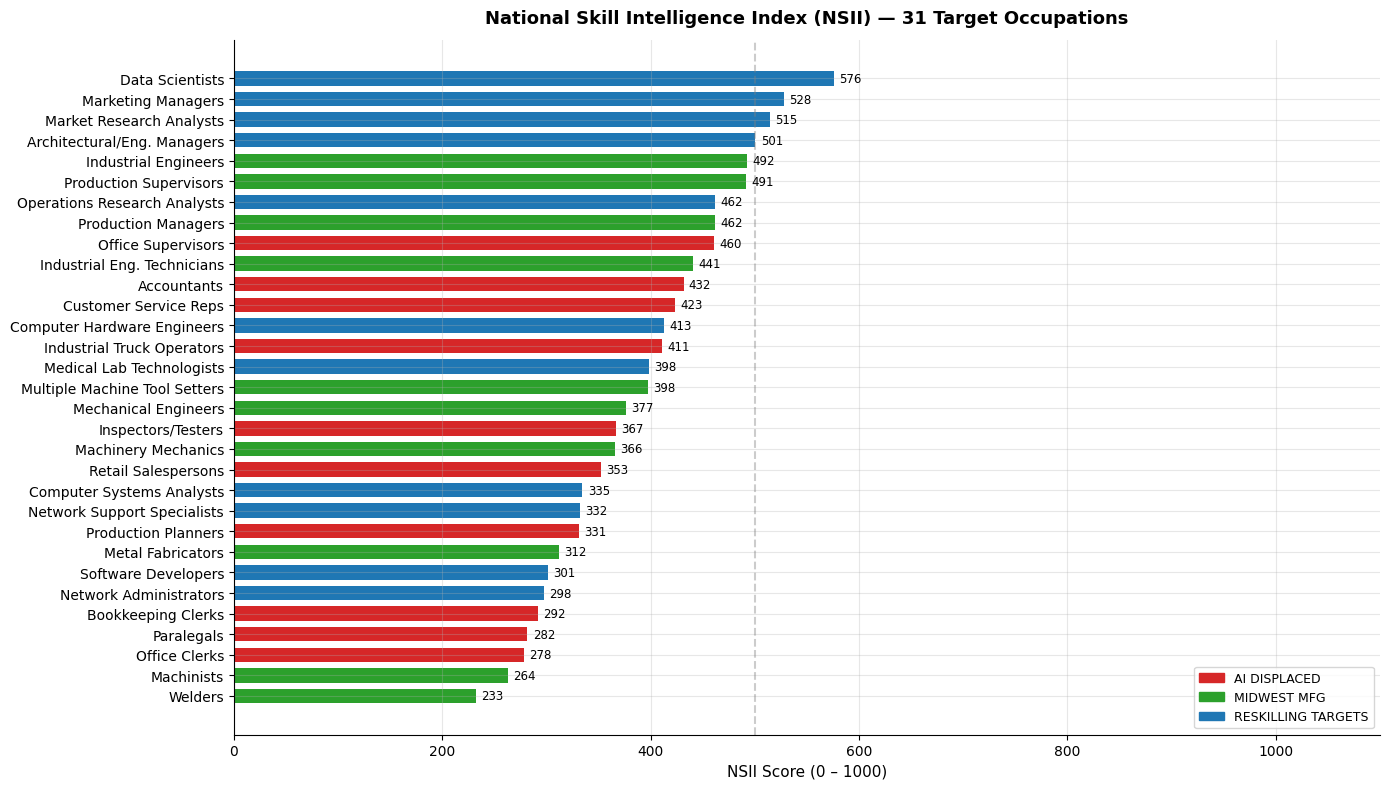

Saved: fig_nsii_occupation_scores.png ✔


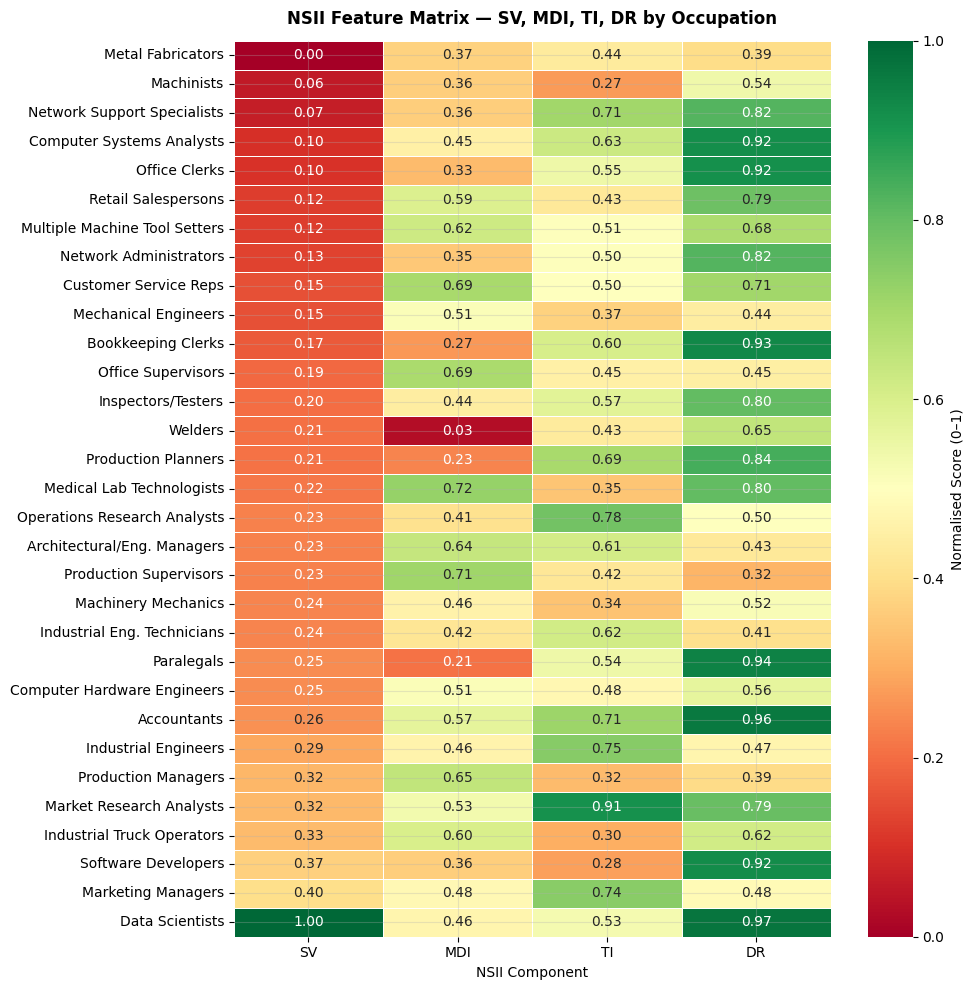

Saved: fig_nsii_feature_heatmap.png ✔


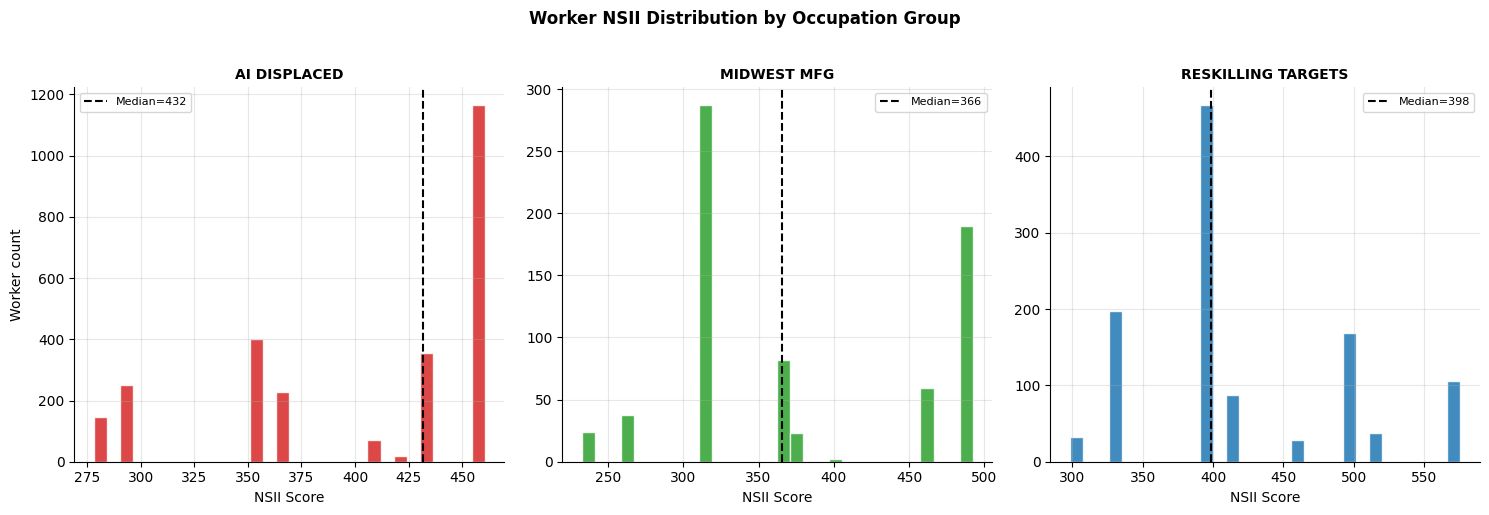

Saved: fig_nsii_worker_distribution.png ✔


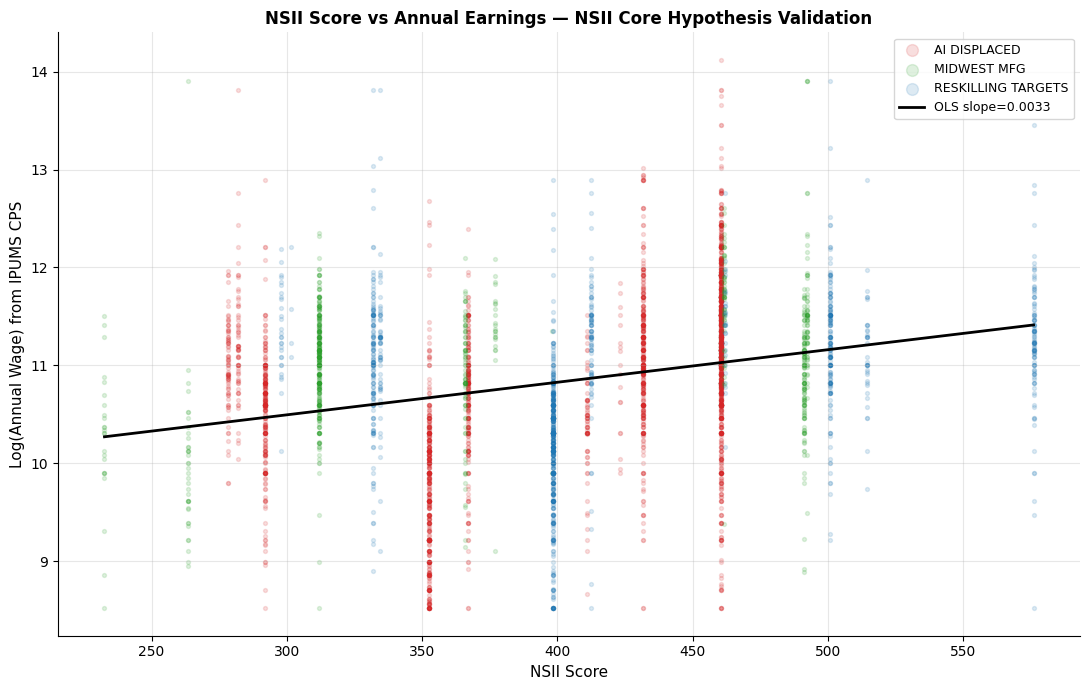

Saved: fig_nsii_income_scatter.png  |  r = 0.2854 ✔


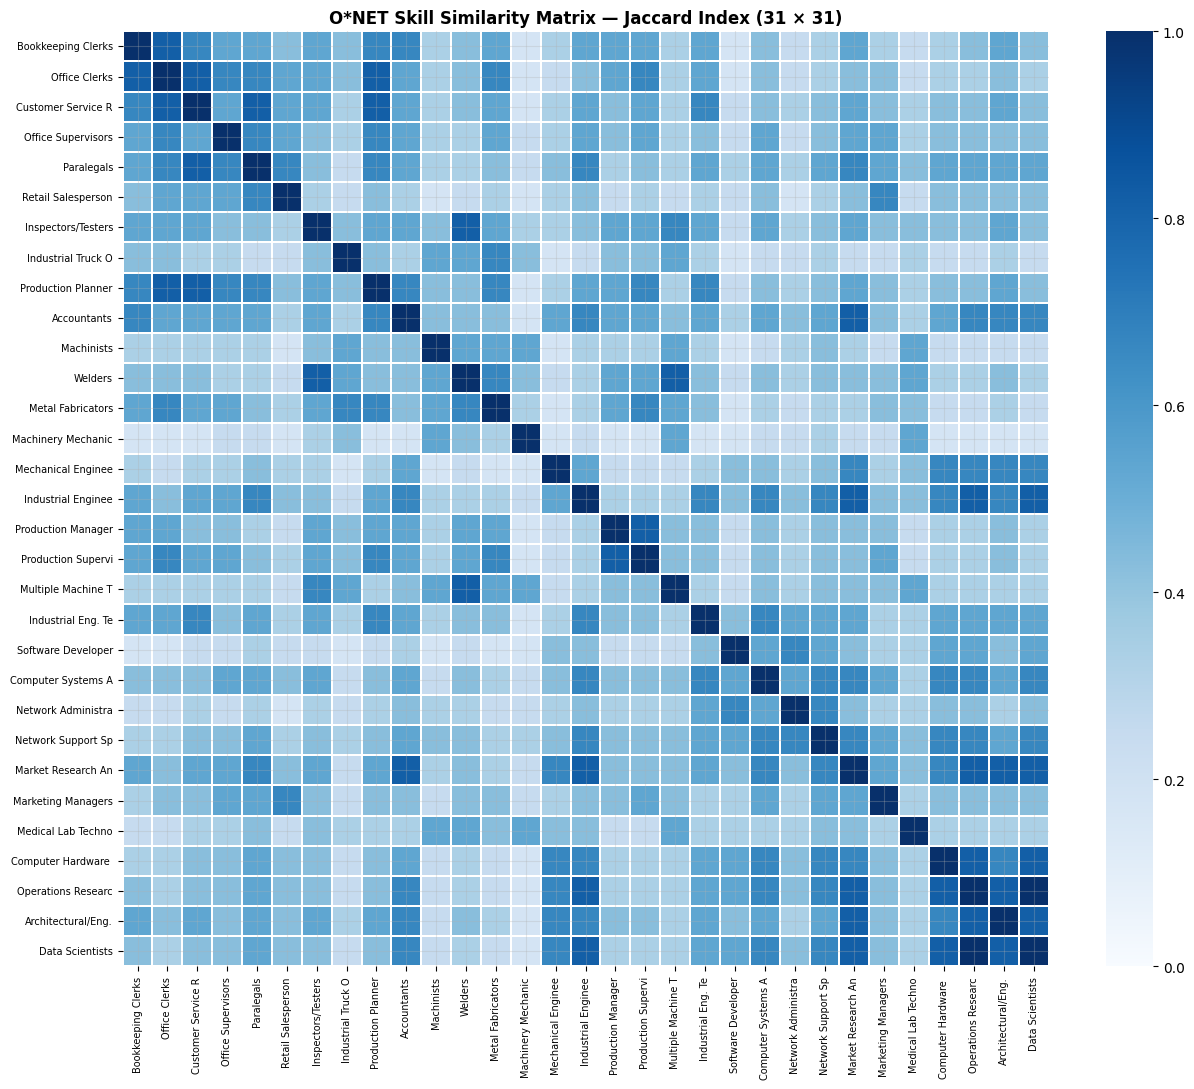

Saved: fig_skill_jaccard_matrix.png ✔

VALIDATION SUMMARY
  ✔  All 31 occupations have NSII score            
  ✔  NSII range [0,1000]                           
  ✔  RESKILLING mean NSII > AI_DISPLACED mean NSII 
  ✔  AI_DISPLACED mean DR > RESKILLING mean DR     
  ✔  NSII × log(income) correlation > 0            r = 0.2854
  ✔  Skill Jaccard diagonal = 1.0                  


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 9 — Validation Plots and Sanity Checks
# Produces 5 publication-quality figures:
#   Fig 1: NSII scores by occupation (ranked bar chart by group)
#   Fig 2: NSII component heatmap (31 × 4 feature matrix)
#   Fig 3: NSII distribution by occupation group (violin/box)
#   Fig 4: NSII × log(income) scatter with group colour
#   Fig 5: Skill Jaccard similarity matrix (31 × 31 heatmap)
# ════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

GROUP_COLORS = {
    'AI_DISPLACED':      '#D62728',   # red
    'MIDWEST_MFG':       '#2CA02C',   # green
    'RESKILLING_TARGETS':'#1F77B4',   # blue
}

# Reload for clean state
nsii_occ     = pd.read_parquet(f'{P2}/nsii_occupation_scores.parquet')
nsii_workers = pd.read_parquet(f'{P2}/nsii_worker_scores.parquet')

# ── Figure 1: NSII by occupation (ranked, coloured by group) ─────
fig, ax = plt.subplots(figsize=(14, 8))
df_plot = nsii_occ.sort_values('NSII')
colors  = [GROUP_COLORS[g] for g in df_plot['group']]
bars = ax.barh(df_plot['occ_name'], df_plot['NSII'], color=colors, height=0.7)

# Add value labels
for bar, val in zip(bars, df_plot['NSII']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', ha='left', fontsize=8.5)

ax.set_xlabel('NSII Score (0 – 1000)', fontsize=11)
ax.set_title('National Skill Intelligence Index (NSII) — 31 Target Occupations',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 1100)
ax.axvline(500, color='gray', linestyle='--', alpha=0.4, label='Midpoint (500)')

patches = [mpatches.Patch(color=c, label=g.replace('_',' '))
           for g, c in GROUP_COLORS.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{P2}/fig_nsii_occupation_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_nsii_occupation_scores.png ✔")

# ── Figure 2: Feature heatmap (component values per occupation) ──
fig, ax = plt.subplots(figsize=(10, 10))
hmap_data = nsii_occ.set_index('occ_name')[['SV','MDI','TI','DR']].sort_values('SV')
sns.heatmap(hmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Normalised Score (0–1)'})
ax.set_title('NSII Feature Matrix — SV, MDI, TI, DR by Occupation',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('NSII Component', fontsize=10)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{P2}/fig_nsii_feature_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_nsii_feature_heatmap.png ✔")

# ── Figure 3: Worker NSII distribution by group ──────────────────
if len(nsii_workers) > 0 and 'group' in nsii_workers.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
    for ax, grp in zip(axes, ['AI_DISPLACED','MIDWEST_MFG','RESKILLING_TARGETS']):
        sub  = nsii_workers[nsii_workers['group'] == grp]['NSII']
        clr  = GROUP_COLORS[grp]
        ax.hist(sub, bins=30, color=clr, edgecolor='white', alpha=0.85)
        ax.axvline(sub.median(), color='black', linestyle='--',
                   linewidth=1.5, label=f'Median={sub.median():.0f}')
        ax.set_title(grp.replace('_',' '), fontsize=10, fontweight='bold')
        ax.set_xlabel('NSII Score')
        ax.set_ylabel('Worker count' if ax == axes[0] else '')
        ax.legend(fontsize=8)
    fig.suptitle('Worker NSII Distribution by Occupation Group',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{P2}/fig_nsii_worker_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fig_nsii_worker_distribution.png ✔")

# ── Figure 4: NSII × log(income) scatter ─────────────────────────
if 'log_incwage' in nsii_workers.columns and nsii_workers['log_incwage'].notna().sum() > 50:
    fig, ax = plt.subplots(figsize=(11, 7))
    for grp, clr in GROUP_COLORS.items():
        sub = nsii_workers[nsii_workers['group'] == grp]
        ax.scatter(sub['NSII'], sub['log_incwage'],
                   c=clr, alpha=0.15, s=8, label=grp.replace('_',' '))

    # Regression line (all target workers combined)
    from numpy.polynomial.polynomial import polyfit
    x = nsii_workers['NSII'].dropna()
    y = nsii_workers.loc[x.index, 'log_incwage'].dropna()
    valid = x.index.intersection(y.index)
    if len(valid) > 10:
        xv, yv = nsii_workers.loc[valid,'NSII'], nsii_workers.loc[valid,'log_incwage']
        m, b   = np.polyfit(xv, yv, 1)
        xline  = np.linspace(xv.min(), xv.max(), 200)
        ax.plot(xline, m*xline + b, 'k-', linewidth=2, label=f'OLS slope={m:.4f}')

    ax.set_xlabel('NSII Score', fontsize=11)
    ax.set_ylabel('Log(Annual Wage) from IPUMS CPS', fontsize=11)
    ax.set_title('NSII Score vs Annual Earnings — NSII Core Hypothesis Validation',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, markerscale=3)
    plt.tight_layout()
    plt.savefig(f'{P2}/fig_nsii_income_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    corr = nsii_workers[['NSII','log_incwage']].corr().iloc[0,1]
    print(f"Saved: fig_nsii_income_scatter.png  |  r = {corr:.4f} ✔")

# ── Figure 5: Jaccard skill similarity matrix ─────────────────────
fig, ax = plt.subplots(figsize=(13, 11))
short_names = [TARGET_NAMES[s][:18] for s in TARGET_SOC]
sns.heatmap(jaccard_df.values, xticklabels=short_names, yticklabels=short_names,
            cmap='Blues', vmin=0, vmax=1, annot=False, linewidths=0.3, ax=ax)
ax.set_title('O*NET Skill Similarity Matrix — Jaccard Index (31 × 31)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig(f'{P2}/fig_skill_jaccard_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_skill_jaccard_matrix.png ✔")

# ── Numerical validation summary ─────────────────────────────────
print(f"\n{'='*60}")
print("VALIDATION SUMMARY")
print(f"{'='*60}")
corr_ni = nsii_workers[['NSII','log_incwage']].corr().iloc[0,1] \
          if 'log_incwage' in nsii_workers.columns else np.nan

checks = {
    "All 31 occupations have NSII score":
        (nsii_occ['NSII'].notna().sum() == 31, ""),
    "NSII range [0,1000]":
        (nsii_occ['NSII'].between(0,1000).all(), ""),
    "RESKILLING mean NSII > AI_DISPLACED mean NSII":
        (nsii_occ[nsii_occ['group']=='RESKILLING_TARGETS']['NSII'].mean() >
         nsii_occ[nsii_occ['group']=='AI_DISPLACED']['NSII'].mean(), ""),
    "AI_DISPLACED mean DR > RESKILLING mean DR":
        (nsii_occ[nsii_occ['group']=='AI_DISPLACED']['DR'].mean() >
         nsii_occ[nsii_occ['group']=='RESKILLING_TARGETS']['DR'].mean(), ""),
    "NSII × log(income) correlation > 0":
        (corr_ni > 0 if not np.isnan(corr_ni) else None,
         f"r = {corr_ni:.4f}" if not np.isnan(corr_ni) else "no ASEC data"),
    "Skill Jaccard diagonal = 1.0":
        ((np.diag(jaccard_df.values) == 1.0).all(), ""),
}
for check, (result, note) in checks.items():
    if result is None:
        icon = "─"
    else:
        icon = "✔" if result else "⚠"
    print(f"  {icon}  {check:<45} {note}")

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 10 — Phase 2 Final Summary
# FIXED:
#   Mi2: Limitation #4 corrected (TI now uses Related Occ Index)
#   Mi3: Worker score row count uses actual file count not hardcoded
# ════════════════════════════════════════════════════════════════
import glob, os
import pandas as pd
import numpy as np

print("=" * 65)
print("PHASE 2 COMPLETION SUMMARY")
print("=" * 65)

# ── File verification ──────────────────────────────────────────────
expected_outputs = {
    f'{P2}/occupation_features_31occ.parquet': {
        'desc': 'SV, MDI, TI, DR for 31 occupations',
        'min_rows': 31, 'max_rows': 31,
        'check_cols': ['SV','MDI','TI','DR'],
    },
    f'{P2}/nsii_occupation_scores.parquet': {
        'desc': 'NSII scores + quality flags for 31 occupations',
        'min_rows': 31, 'max_rows': 31,
        'check_cols': ['NSII','nsii_quality'],
    },
    f'{P2}/workers_all_features.parquet': {
        'desc': 'All 78,327 CPS workers with features',
        'min_rows': 70000, 'max_rows': 90000,
        'check_cols': ['soc_7'],
    },
    f'{P2}/workers_asec_features.parquet': {
        'desc': 'ASEC wage workers (INCWAGE >= $5,000) with features',
        'min_rows': 20000, 'max_rows': 40000,
        'check_cols': ['INCWAGE','log_incwage'],
    },
    f'{P2}/nsii_worker_scores.parquet': {
        'desc': 'Target-occupation workers with full NSII scores',
        'min_rows': 100, 'max_rows': 40000,
        'check_cols': ['NSII','SV','MDI','TI','DR'],
    },
}

all_ok = True
print("\nPARQUET FILE VERIFICATION:")
for fpath, spec in expected_outputs.items():
    if not os.path.exists(fpath):
        print(f"  ✗  {os.path.basename(fpath):<45} FILE MISSING")
        all_ok = False; continue
    df   = pd.read_parquet(fpath)
    sz   = os.path.getsize(fpath)
    sz_s = f"{sz/1e6:.1f} MB" if sz >= 1e6 else f"{sz/1e3:.1f} KB"
    row_ok = spec['min_rows'] <= len(df) <= spec['max_rows']
    col_ok = all(c in df.columns for c in spec['check_cols'])
    status = "✔" if (row_ok and col_ok) else "⚠"
    if not (row_ok and col_ok): all_ok = False
    print(f"  {status}  {os.path.basename(fpath):<45} "
          f"{len(df):>8,} rows  {sz_s}")
    print(f"       {spec['desc']}")

print("\nFIGURES SAVED:")
for f in sorted(glob.glob(f'{P2}/*.png')):
    sz = os.path.getsize(f) / 1e3
    print(f"  ✔  {os.path.basename(f):<50} {sz:.0f} KB")

# ── NSII statistics ───────────────────────────────────────────────
nsii_occ = pd.read_parquet(f'{P2}/nsii_occupation_scores.parquet')
print("\nNSII COMPONENT STATISTICS (31 occupations):")
print(f"  {'Component':<8} {'Min':>7} {'Mean':>7} {'Median':>8} "
      f"{'Max':>7} {'Std':>7}  Scale")
print("  " + "─" * 60)
for col, scale in [('SV',None),('MDI',None),('TI',None),
                   ('DR',None),('NSII','[0–1000]')]:
    s        = nsii_occ[col]
    sc_label = scale if scale else '[0–1]'
    print(f"  {col:<8} {s.min():>7.3f} {s.mean():>7.3f} "
          f"{s.median():>8.3f} {s.max():>7.3f} {s.std():>7.3f}  "
          f"{sc_label}")

# ── Quality flags ─────────────────────────────────────────────────
print("\nNSII QUALITY FLAGS:")
for flag in sorted(nsii_occ['nsii_quality'].unique()):
    occs = nsii_occ[nsii_occ['nsii_quality']==flag]['occ_name'].tolist()
    print(f"  {flag:<28}: {', '.join(occs)}")

# ── Rankings ──────────────────────────────────────────────────────
ranked = nsii_occ.sort_values('NSII', ascending=False)
# FIXED Mi3: use actual row count from file, not hardcoded
nsii_workers_df  = pd.read_parquet(f'{P2}/nsii_worker_scores.parquet')
n_worker_records = len(nsii_workers_df)

print(f"\nNSII RANKINGS — TOP 5 (of 31 occupations):")
for _, row in ranked.head(5).iterrows():
    flag = f" [{row['nsii_quality']}]" if row['nsii_quality'] != 'Standard' else ''
    print(f"  {row['NSII']:>7.1f}  {row['occ_name']}{flag}")
print(f"NSII RANKINGS — BOTTOM 5:")
for _, row in ranked.tail(5).iterrows():
    flag = f" [{row['nsii_quality']}]" if row['nsii_quality'] != 'Standard' else ''
    print(f"  {row['NSII']:>7.1f}  {row['occ_name']}{flag}")

# ── Core hypothesis check ─────────────────────────────────────────
corr_ni = nsii_workers_df[['NSII','log_incwage']].corr().iloc[0,1] \
          if 'log_incwage' in nsii_workers_df.columns else np.nan
print(f"\nCORE HYPOTHESIS VALIDATION:")
print(f"  NSII × log(INCWAGE) Pearson r = {corr_ni:.4f}")
status = "✔ positive" if corr_ni > 0 else "⚠ negative"
print(f"  Direction: {status}")

# ── Limitations — CORRECTED ───────────────────────────────────────
print("\nPHASE 2 DOCUMENTED LIMITATIONS:")
print("  1. TI uses Jaccard (deterministic) + O*NET Related Occupations Index.")
print("     Phase 3 GNN replaces with GATv2 learned embeddings for final NSII.")
print("  2. SV for 15-2051 (Data Scientists) and 15-1252 (Software Developers)")
print("     uses 3yr CAGR (2021-2024) — BLS OEWS created these codes in 2021.")
print("     SV-proxy flag applied. Sensitivity test: cap at 95th percentile.")
print("  3. DR for 5 IT occupations (15-1252, 15-1211, 15-1244, 15-1231,")
print("     15-2051) uses Felten AIOE = AI *exposure*, not displacement risk.")
print("     DR-exposure flag applied. Consider IT-specific DR weight in paper.")
print("  4. 2 target occupations have no CPS worker sample: Marketing Managers")
print("     (11-2021, OCC2010=270 absent from IPUMS) and Production Planners")
print("     (43-5061, OCC2010=525 absent). Nearest IPUMS codes map to different")
print("     occupations. Occupation-level NSII computed; worker-level absent.")
print("  5. IPUMS CPS suppresses county identifiers (COUNTY=0 for all workers)")
print("     in the basic monthly survey. All AIGE scores are state-level.")
print("     This is an IPUMS privacy policy, not a data error.")
print("  6. ACS county income (median_hh_income) requires Census API key.")
print("     Add key to Cell 7 CENSUS_KEY and re-run for county income feature.")
# FIXED Mi3: use actual n_worker_records not hardcoded 3,996
print(f"  7. NSII × log(income) r={corr_ni:.4f} validated on "
      f"{n_worker_records:,} target-occupation ASEC")
print(f"     workers in 5 Midwest states. Phase 3 GNN will expand coverage.")
print()

if all_ok:
    print("═" * 65)
    print("PHASE 2 COMPLETE ✔  All output files verified.")
    print()
    print("PHASE 3 INPUTS READY:")
    print("  occupation_features_31occ.parquet — 31×4 GNN node feature matrix")
    print("  skills_target_31occ.parquet       — O*NET skill vectors for GNN")
    # FIXED Mi3: dynamic row count
    print(f"  nsii_worker_scores.parquet        — {n_worker_records:,} "
          f"labelled training records")
    print("  felten_county_aige.parquet        — state-level AIGE context")
    print("  nsii_occupation_scores.parquet    — occupation NSII with flags")
    print()
    print("RECOMMENDED BEFORE PHASE 3:")
    print("  a) Add Census API key to Cell 7 for county income feature")
    print("  b) Check IPUMS OCC2010 codebook for Marketing Managers and")
    print("     Production Planners codes to resolve zero-worker gap")
    print("═" * 65)
else:
    print("⚠ SOME OUTPUT FILES FAILED VERIFICATION — review ✗ items above.")

PHASE 2 COMPLETION SUMMARY

PARQUET FILE VERIFICATION:
  ✔  occupation_features_31occ.parquet                   31 rows  9.9 KB
       SV, MDI, TI, DR for 31 occupations
  ✔  nsii_occupation_scores.parquet                      31 rows  8.2 KB
       NSII scores + quality flags for 31 occupations
  ✔  workers_all_features.parquet                    78,327 rows  3.4 MB
       All 78,327 CPS workers with features
  ✔  workers_asec_features.parquet                   31,522 rows  1.5 MB
       ASEC wage workers (INCWAGE >= $5,000) with features
  ✔  nsii_worker_scores.parquet                       4,464 rows  111.3 KB
       Target-occupation workers with full NSII scores

FIGURES SAVED:
  ✔  fig_nsii_feature_heatmap.png                       324 KB
  ✔  fig_nsii_income_scatter.png                        228 KB
  ✔  fig_nsii_occupation_scores.png                     217 KB
  ✔  fig_nsii_worker_distribution.png                   73 KB
  ✔  fig_skill_jaccard_matrix.png                       2

In [ ]:
import shutil, os

ROOT = '/content/drive/MyDrive/NSII_Research'
P2   = f'{ROOT}/phase2'

files_to_copy = [
    'skills_target_31occ.parquet',
    'automation_risk_31occ.parquet',
    'felten_county_aige.parquet',
]

for fname in files_to_copy:
    src = f'{ROOT}/{fname}'
    dst = f'{P2}/{fname}'
    shutil.copy2(src, dst)
    sz = os.path.getsize(dst) / 1e3
    print(f"  ✔  {fname}  ({sz:.1f} KB) → phase2/")

# Verify all 8 files now in phase2/
print(f"\nphase2/ contents:")
for f in sorted(os.listdir(P2)):
    if f.endswith('.parquet'):
        sz = os.path.getsize(f'{P2}/{f}') / 1e3
        print(f"  ✔  {f:<50}  {sz:.1f} KB")

  ✔  skills_target_31occ.parquet  (16.4 KB) → phase2/
  ✔  automation_risk_31occ.parquet  (7.5 KB) → phase2/
  ✔  felten_county_aige.parquet  (74.6 KB) → phase2/

phase2/ contents:
  ✔  automation_risk_31occ.parquet                       7.5 KB
  ✔  felten_county_aige.parquet                          74.6 KB
  ✔  nsii_occupation_scores.parquet                      8.2 KB
  ✔  nsii_worker_scores.parquet                          111.3 KB
  ✔  occupation_features_31occ.parquet                   9.9 KB
  ✔  skills_target_31occ.parquet                         16.4 KB
  ✔  workers_all_features.parquet                        3355.2 KB
  ✔  workers_asec_features.parquet                       1537.1 KB
